<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_Previs%C3%A3o_de_Vendas_diarias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho: Previsão de Vendas diária**

O objetivo principal é transformar dados transacionais em uma série temporal e realizar a previsão de vendas diárias para um departamento específico.

**1. Preparação dos Dados (Data Prep):**

Agregação: Converter as transações em uma série diária, utilizando a soma do valor das vendas como método de acumulação.

*   Saneamento
*   Datas Faltantes: Identificar lacunas no calendário e preenchê-las (imputação ou zero) para garantir que a série seja igualmente espaçada.
*  Vendas Negativas: Tratar valores negativos (erros de registro) por meio de imputação, como a média do período.

Foco da Análise: Priorizar os Departamentos 2 ou 4, que juntos representam cerca de 95% do faturamento total.

**2. Estratégia de Modelagem:**

Divisão da Base: Utilizar os anos de 2018, 2019 e 2020 para treino e o ano de 2021 para teste (Holdout).

Análise Inicial:

* Visualização: Plotar recortes da série para identificar tendência e sazonalidade.

* Testes Estatísticos: Validar se a série é Ruído Branco (se for, não há padrão para prever) e verificar a Estacionariedade.

**3. Execução e Avaliação:**

Escolha do Modelo: Identificar se há tendência e sazonalidade para selecionar a técnica adequada (Alisamento Exponencial Simples, Holt ou Holt-Winters).

Validação:
* Comparar os valores previstos com os reais da base de teste (2021).

* Calcular métricas de erro (como o MAPE) e garantir que os resíduos do modelo se comportem como ruído branco, provando que o sinal foi capturado corretamente.
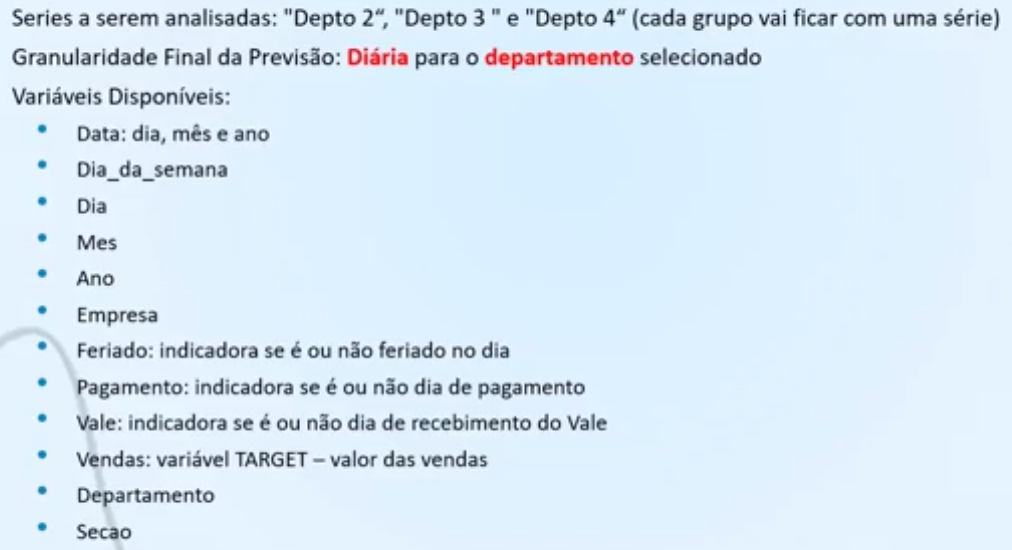

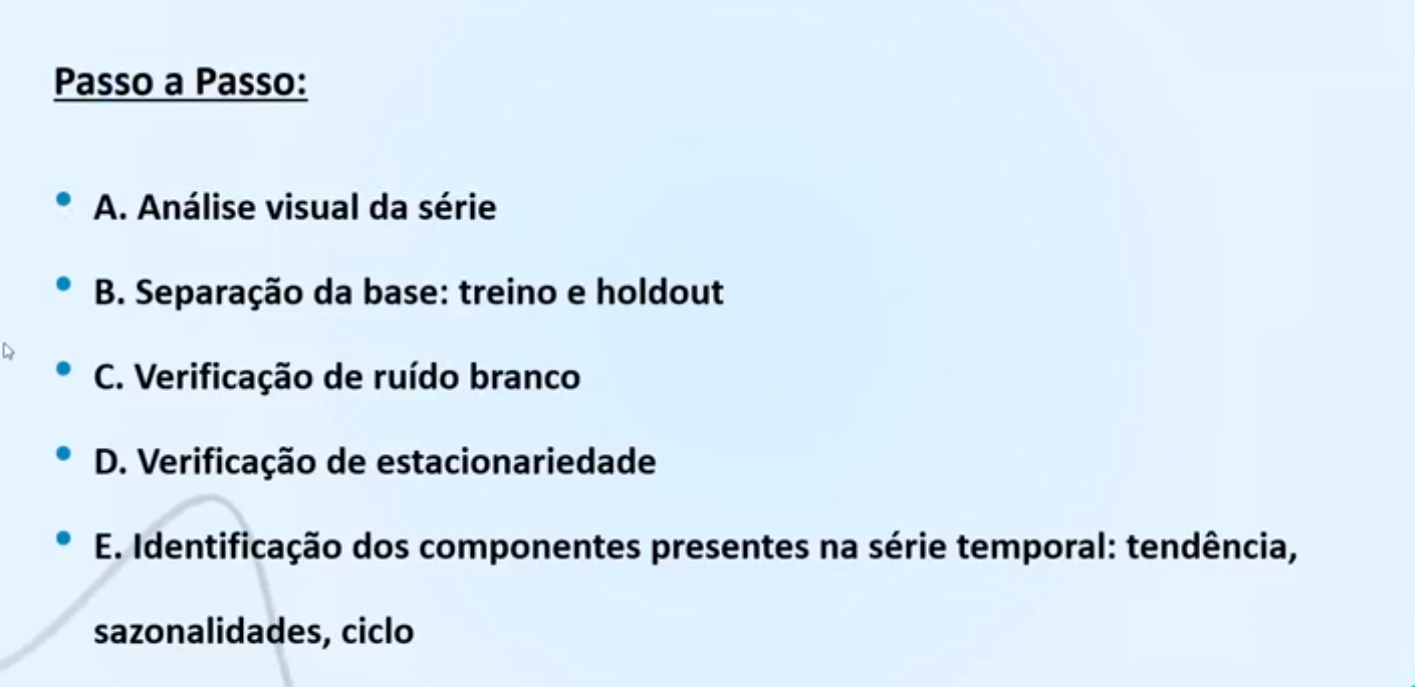

BIBLIOTECAS

In [75]:
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import (SimpleExpSmoothing,ExponentialSmoothing,Holt)
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

import dateutil
import calendar

import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from math import sqrt

print('✅ Bibliotecas carregadas!')

✅ Bibliotecas carregadas!


1. CARREGAR DADOS

In [76]:
!pip install gdown # ponte entre Google Drive e Python

In [77]:
import gdown

file_id = "1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Vendas_ASN_Dados_Finais.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW
To: /content/Vendas_ASN_Dados_Finais.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 122MB/s]


'Vendas_ASN_Dados_Finais.csv'

In [78]:
data = pd.read_csv('Vendas_ASN_Dados_Finais.csv')
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [79]:
# ver formato que está a data

data = data.drop(columns=['Data_new'])
data.head(10)

,Data,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [80]:
data['Data'] = pd.to_datetime(data['Data'])

/tmp/ipykernel_949/3475004564.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Data'] = pd.to_datetime(data['Data'])


In [81]:
data['Data'].head()
data['Data'].dtype

dtype('<M8[ns]')

In [82]:
data['Data_BR'] = data['Data'].dt.strftime('%d/%m/%Y')

data['Data_BR'] = pd.to_datetime(
    data['Data_BR'],
    format='%d/%m/%Y'
)

In [83]:
data['Data_BR'].dtype

dtype('<M8[ns]')

In [84]:
# Data no formato brasileiro e como data:

data.head(10)

,Data,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção,Data_BR
0,2018-01-02,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1,2018-01-02
1,2018-01-02,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2,2018-01-02
2,2018-01-02,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3,2018-01-02
3,2018-01-02,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4,2018-01-02
4,2018-01-02,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7,2018-01-02
5,2018-01-02,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26,2018-01-02
6,2018-01-02,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5,2018-01-02
7,2018-01-02,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6,2018-01-02
8,2018-01-02,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7,2018-01-02
9,2018-01-02,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8,2018-01-02


2. TRANSFORMAR DADOS TRANSACIONAIS EM AGREGADOS

Método de acumulação - soma

Intervalo de tempo - diária

In [85]:
data['Vendas'] = (
    data['Vendas']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# QUANTAS VENDAS TEM POR DEPARTAMENTO?

total_departamento = (
    data.groupby('Departamento', as_index=False)['Vendas']
      .sum()
)

# Total geral
total_geral = total_departamento['Vendas'].sum()

# Percentual de participação
total_departamento['Perc'] = (
    total_departamento['Vendas'] / total_geral * 100
)

# Valor em milhões
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas'] / 1_000_000
)

# Formatação
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas_MM']
    .map(lambda x: f'{x:,.2f} MM')
)

total_departamento['Perc'] = (
    total_departamento['Perc']
    .map(lambda x: f'{x:.2f}%')
)

print(total_departamento)

  Departamento        Vendas    Perc    Vendas_MM
0      Depto 1  5.295840e+06   0.09%      5.30 MM
1      Depto 2  3.265787e+09  54.12%  3,265.79 MM
2     Depto 3   2.474437e+08   4.10%    247.44 MM
3      Depto 4  2.460234e+09  40.77%  2,460.23 MM
4      Depto 5  5.052954e+07   0.84%     50.53 MM
5      Depto 6  4.219464e+06   0.07%      4.22 MM
6      Depto 7  9.759944e+05   0.02%      0.98 MM


Para continuar a análise, foi escolhido o departamento 4 por representar 41% das vendas.

In [96]:
# Filtrar apenas o Depto 4
data_depto4 = data[data['Departamento'] == 'Depto 4']

# Verificar se existe alguma venda negativa
tem_negativo = (data_depto4['Vendas'] < 0).any()
print("Existe venda negativa?", tem_negativo)

# Listar todas as linhas com vendas negativas
vendas_negativas = data_depto4[data_depto4['Vendas'] < 0]
print(vendas_negativas)

Existe venda negativa? True
             Data  Dia_da_semana  Dia  Mes   Ano  Empresa  Feriado  Pagamento  \
288456 2020-11-23              2   23   11  2020       23        0          0   

        Vale  Vendas Departamento     Seção    Data_BR  
288456     0   -5.66      Depto 4  Seção 20 2020-11-23  


In [97]:
vendas_dia = (
    data_depto4.groupby(['Data_BR'])['Vendas']
      .sum()
      .reset_index()
)

print(vendas_dia)


        Data_BR      Vendas
0    2018-01-02  1812134.19
1    2018-01-03  1622115.60
2    2018-01-04  1486888.42
3    2018-01-05  2015469.36
4    2018-01-06  2678387.64
...         ...         ...
1143 2021-02-24  2025751.85
1144 2021-02-25  2216224.47
1145 2021-02-26  3098829.40
1146 2021-02-27  4592539.97
1147 2021-02-28  2157356.38

[1148 rows x 2 columns]


In [13]:
# ANÁLISE DA VARIÁVEL VENDA:

vendas_dia['Vendas'].describe()

,Vendas
count,1.148000e+03
mean,2.143061e+06
std,7.398696e+05
min,5.802061e+05
25%,1.632986e+06
50%,1.954044e+06
75%,2.459384e+06
max,5.363986e+06


In [14]:
vendas_dia['Ano'] = vendas_dia['Data_BR'].dt.year

vendas_dia.head(10)

,Data_BR,Vendas,Ano
0,2018-01-02,1812134.19,2018
1,2018-01-03,1622115.60,2018
2,2018-01-04,1486888.42,2018
3,2018-01-05,2015469.36,2018
4,2018-01-06,2678387.64,2018
5,2018-01-07,1120660.99,2018
6,2018-01-08,1600882.79,2018
7,2018-01-09,1963629.68,2018
8,2018-01-10,1667902.81,2018
9,2018-01-11,1457775.73,2018


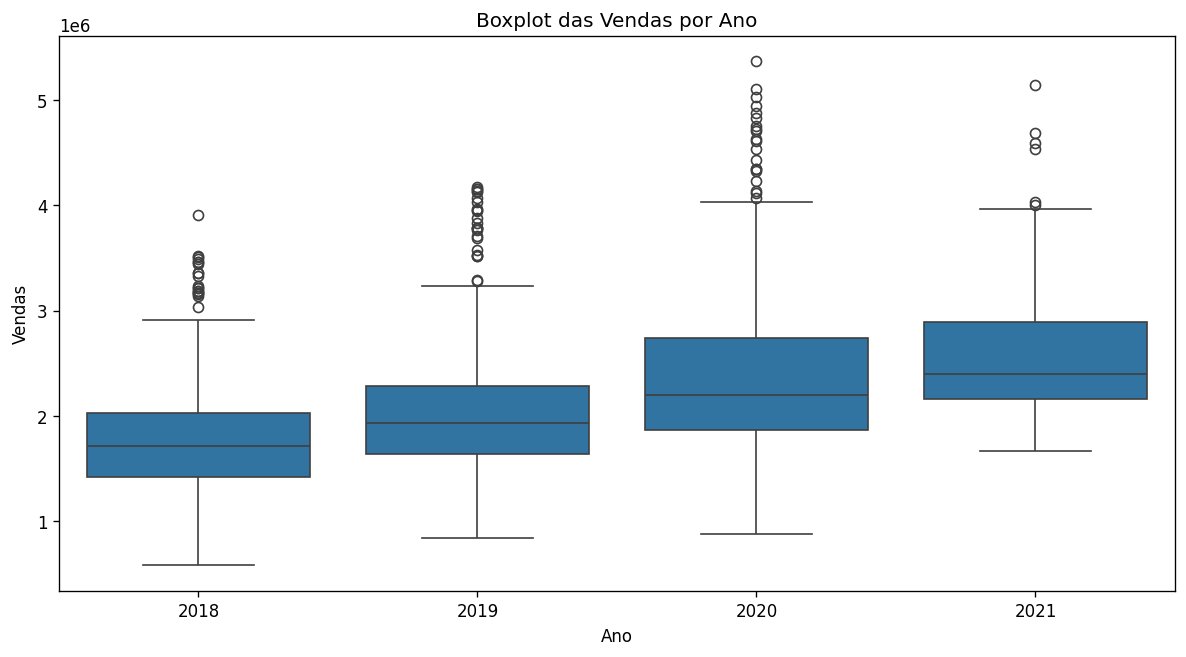

In [15]:
# BOXPLOT AO LONGO DOS ANOS:

fig, ax = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=vendas_dia,
    x='Ano',
    y='Vendas',
    ax=ax
)

plt.title('Boxplot das Vendas por Ano')
plt.show()

In [16]:
vendas_dia.groupby('Ano')['Vendas'].describe()

,count,mean,std,min,25%,50%,75%,max
Ano,,,,,,,,
2018,363.0,1.827837e+06,579069.807873,580206.06,1.415357e+06,1710038.510,2.025495e+06,3906138.25
2019,363.0,2.089768e+06,640858.788881,836348.22,1.637741e+06,1932448.020,2.283950e+06,4168269.68
2020,364.0,2.427573e+06,814747.069522,878158.71,1.863710e+06,2201581.005,2.734793e+06,5363986.16
2021,58.0,2.663906e+06,778574.868966,1667474.63,2.161169e+06,2399303.330,2.891777e+06,5141515.66


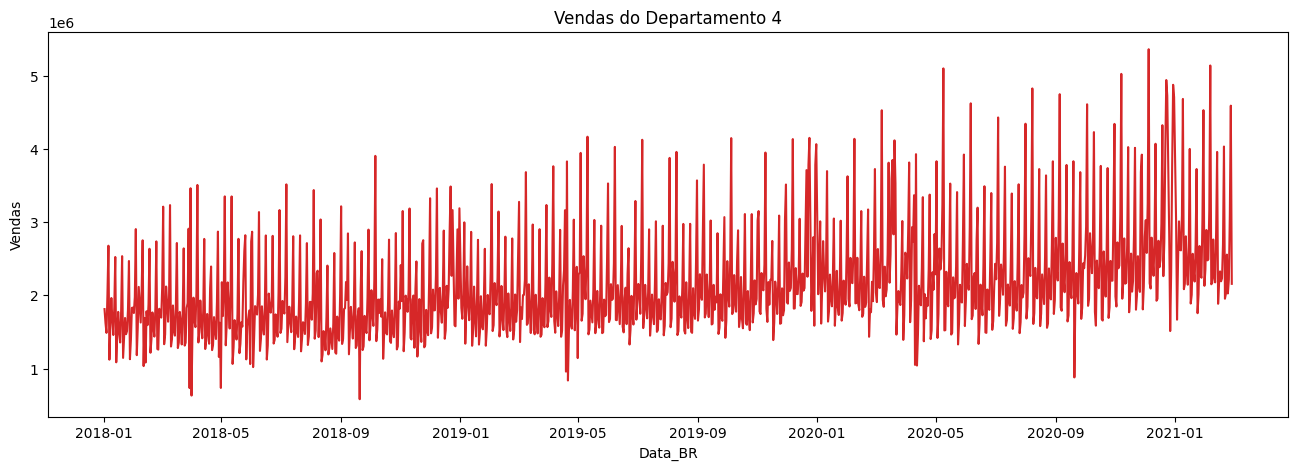

In [17]:
# Visualizando a série temporal

def plot_df(vendas_dia, x, y, title="", xlabel='Data_BR', ylabel='Vendas', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(
    vendas_dia=vendas_dia,
    x=vendas_dia['Data_BR'],
    y=vendas_dia['Vendas'],
    title='Vendas do Departamento 4'
)

In [18]:
print(vendas_dia['Vendas'].isna().sum())
print(vendas_dia.shape)
print(vendas_dia.info())

0
(1148, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1148 entries, 0 to 1147
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Data_BR  1148 non-null   datetime64[ns]
 1   Vendas   1148 non-null   float64       
 2   Ano      1148 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 22.6 KB
None


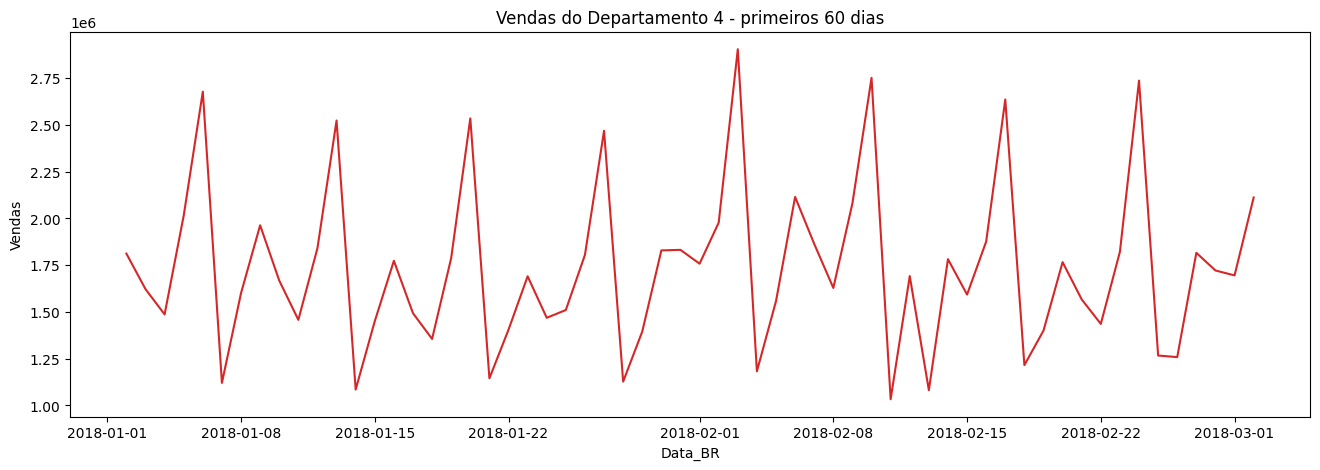

In [43]:
# Visualizando a série temporal em um intervalo de tempo menor

vendas_dia = vendas_dia.sort_values('Data_BR')

trecho = vendas_dia.iloc[:60]

plot_df(
    vendas_dia=trecho,
    x=trecho['Data_BR'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - primeiros 60 dias'
)

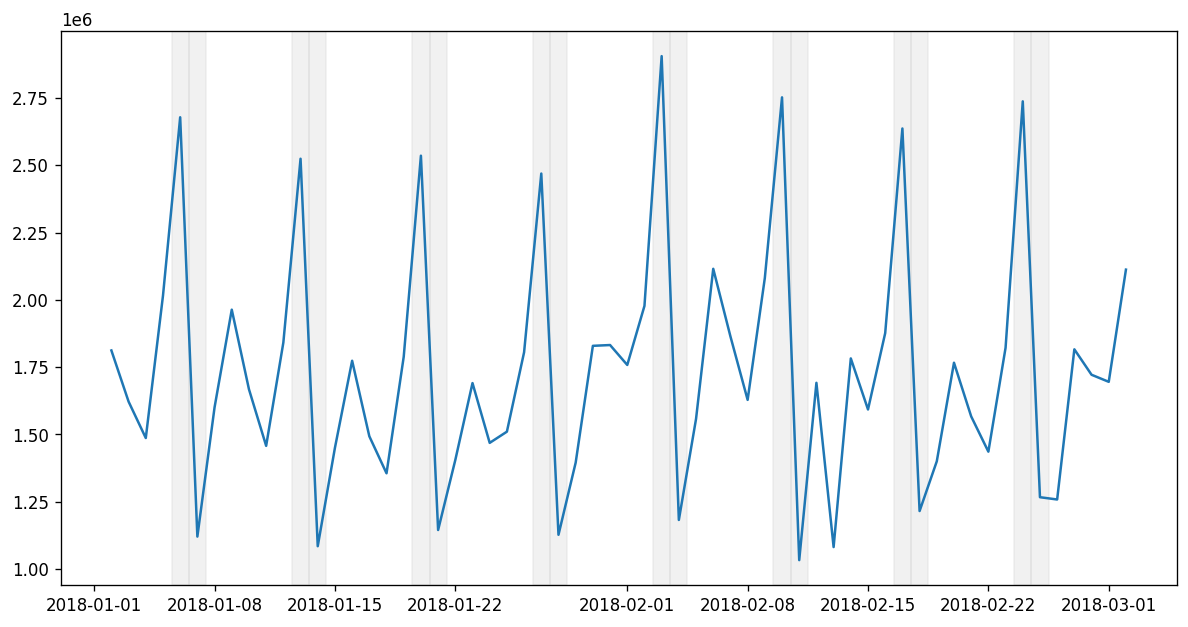

In [45]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(trecho['Data_BR'], trecho['Vendas'])

# destacar finais de semana
for data in trecho.loc[trecho['Data_BR'].dt.dayofweek >= 5, 'Data_BR']:
    ax.axvspan(
        data - pd.Timedelta(hours=12),
        data + pd.Timedelta(hours=12),
        color='lightgray',
        alpha=0.3
    )
title='Vendas do Departamento 4 - primeiros 60 dias'
plt.show()

A série temporal apresenta comportamento predominantemente estacionário, sem tendência definida no período analisado. Observam-se oscilações diárias em torno de um nível médio aproximadamente constante, acompanhadas de elevada variabilidade e indícios de sazonalidade de curta duração, possivelmente semanal.

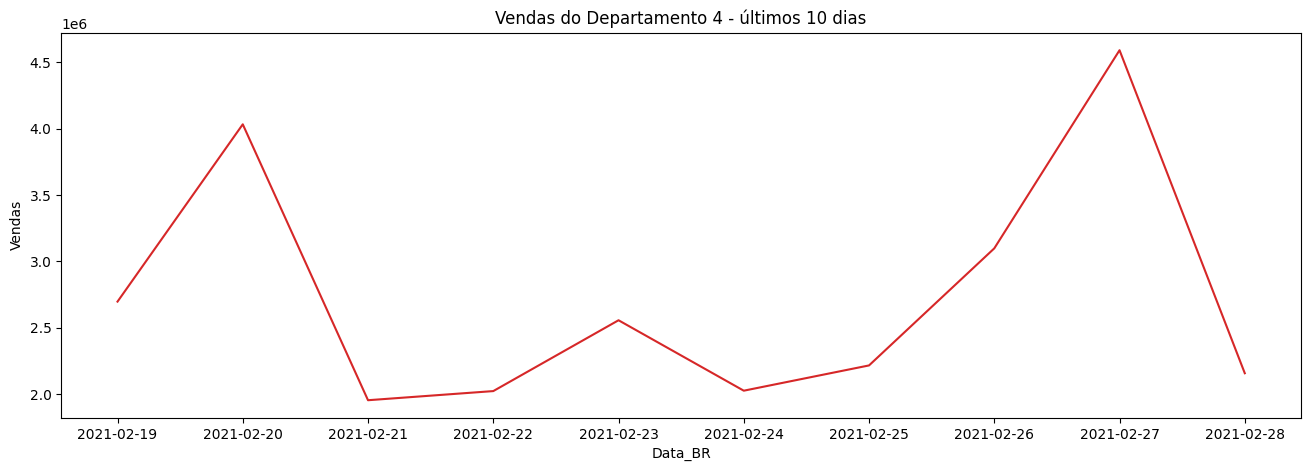

In [20]:
trecho = vendas_dia.iloc[-10:]

plot_df(
    vendas_dia=trecho,
    x=trecho['Data_BR'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - últimos 10 dias'
)

In [21]:
# Tem dias faltantes?
datas_completas = pd.date_range(
    start=vendas_dia['Data_BR'].min(),
    end=vendas_dia['Data_BR'].max(),
    freq='D'
)

faltantes = datas_completas.difference(vendas_dia['Data_BR'])

print(faltantes)
print('Quantidade de dias faltantes:', len(faltantes))

DatetimeIndex(['2018-12-25', '2019-01-01', '2019-12-25', '2020-01-01',
               '2020-12-25', '2021-01-01'],
              dtype='datetime64[ns]', freq=None)
Quantidade de dias faltantes: 6


In [22]:
# Imputar dias faltantes pela média do dia da semana no mes/ano

# Garantir formato datetime
vendas_dia['Data_BR'] = pd.to_datetime(vendas_dia['Data_BR'])

# Criar calendário completo
datas = pd.date_range(
    vendas_dia['Data_BR'].min(),
    vendas_dia['Data_BR'].max(),
    freq='D'
)

# Inserir datas faltantes
serie = (
    vendas_dia
    .set_index('Data_BR')
    .reindex(datas)
    .rename_axis('Data_BR')
    .reset_index()
)

# Variáveis auxiliares
serie['Ano'] = serie['Data_BR'].dt.year
serie['Mes'] = serie['Data_BR'].dt.month
serie['DiaSemana'] = serie['Data_BR'].dt.dayofweek

# Marcar observações originalmente faltantes
serie['Imputado'] = serie['Vendas'].isna()

# Média do mesmo dia da semana dentro do mesmo mês/ano
serie['Media_DS'] = (
    serie
    .groupby(['Ano','Mes','DiaSemana'])['Vendas']
    .transform('mean')
)

# Imputação
serie['Vendas'] = serie['Vendas'].fillna(serie['Media_DS'])

# Remover coluna auxiliar
serie.drop(columns='Media_DS', inplace=True)

In [23]:
serie.loc[serie['Imputado'], ['Data_BR','Vendas']]

,Data_BR,Vendas
357,2018-12-25,2.103518e+06
364,2019-01-01,2.127077e+06
722,2019-12-25,2.048224e+06
729,2020-01-01,2.024906e+06
1088,2020-12-25,3.006982e+06
1095,2021-01-01,2.875630e+06


## **DECOMPOSIÇÃO DA SÉRIE:**

ADITIVA E MULTIPLICATIVA

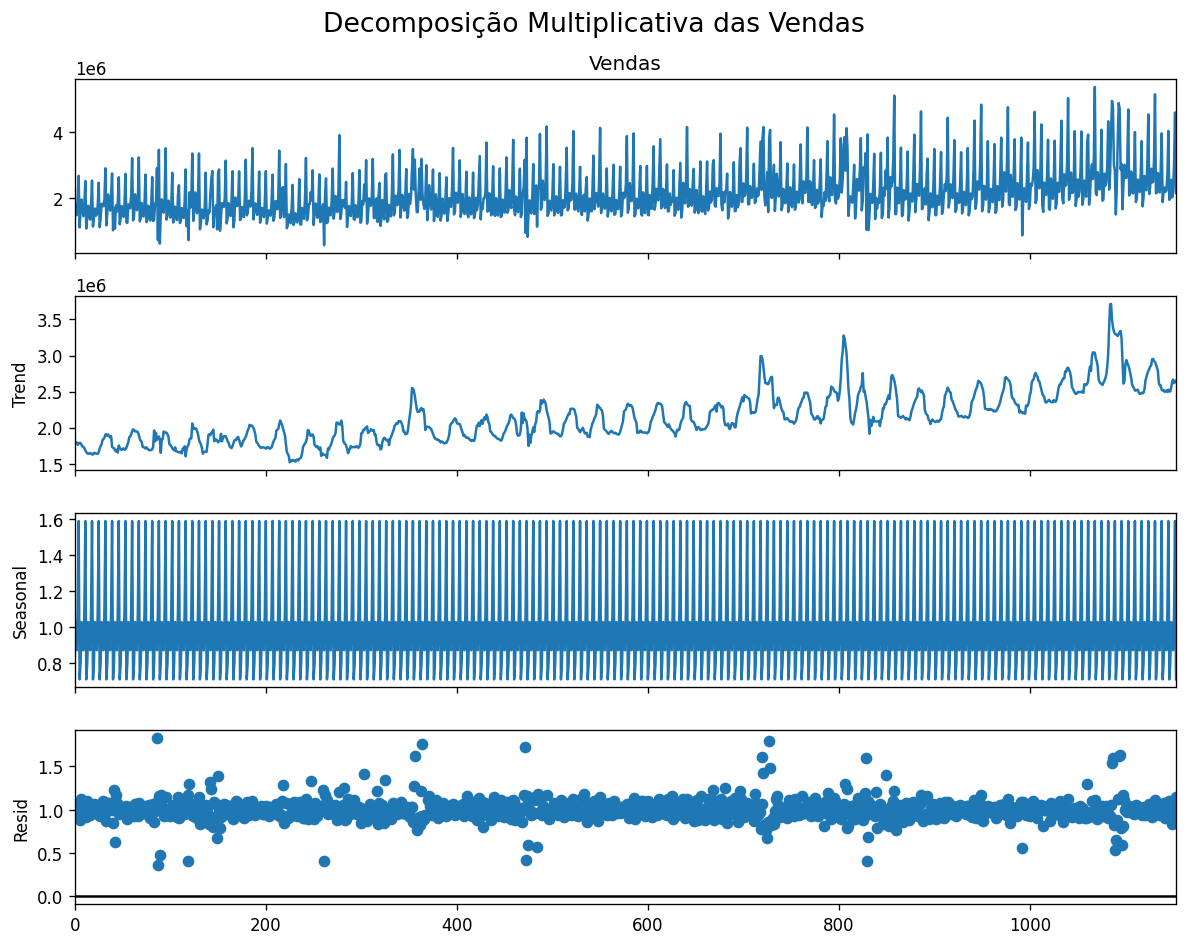

In [24]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

result_mul = seasonal_decompose(
    serie['Vendas'],
    model='multiplicative',
    period=7, # semanal
    extrapolate_trend='freq'
)

plt.rcParams.update({'figure.figsize': (10,8)})

result_mul.plot()

plt.suptitle(
    'Decomposição Multiplicativa das Vendas',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [25]:
serie['Vendas'].isna().sum()

np.int64(0)

**Interpretação da decomposição:**

1. Série original (Vendas)

O primeiro gráfico mostra:

*   tendência crescente ao longo do tempo;
*   oscilações frequentes;
*  aumento da amplitude das vendas nos anos mais recentes;
*  alguns picos bastante elevados, principalmente em 2020 e 2021.

2. Tendência (Trend)

O componente de tendência mostra claramente:

*  crescimento gradual das vendas entre 2018 e 2021;
*  algumas oscilações acentuadas em 2020;
*  um pico importante próximo ao início de 2021.

Isso sugere que o departamento apresentou crescimento nas vendas ao longo do período analisado.

3. Sazonalidade (Seasonal)

A sazonalidade está muito regular (padrão semanal).
determinados dias da semana vendem cerca de 12% acima da média, enquanto outros ficam aproximadamente 10% abaixo.

4. Resíduos (Resid)

Os resíduos parecem:

*  relativamente centrados em torno de 1;
*  sem tendência aparente;
*  com alguns pontos extremos.

Isso é um bom sinal para um modelo multiplicativo.


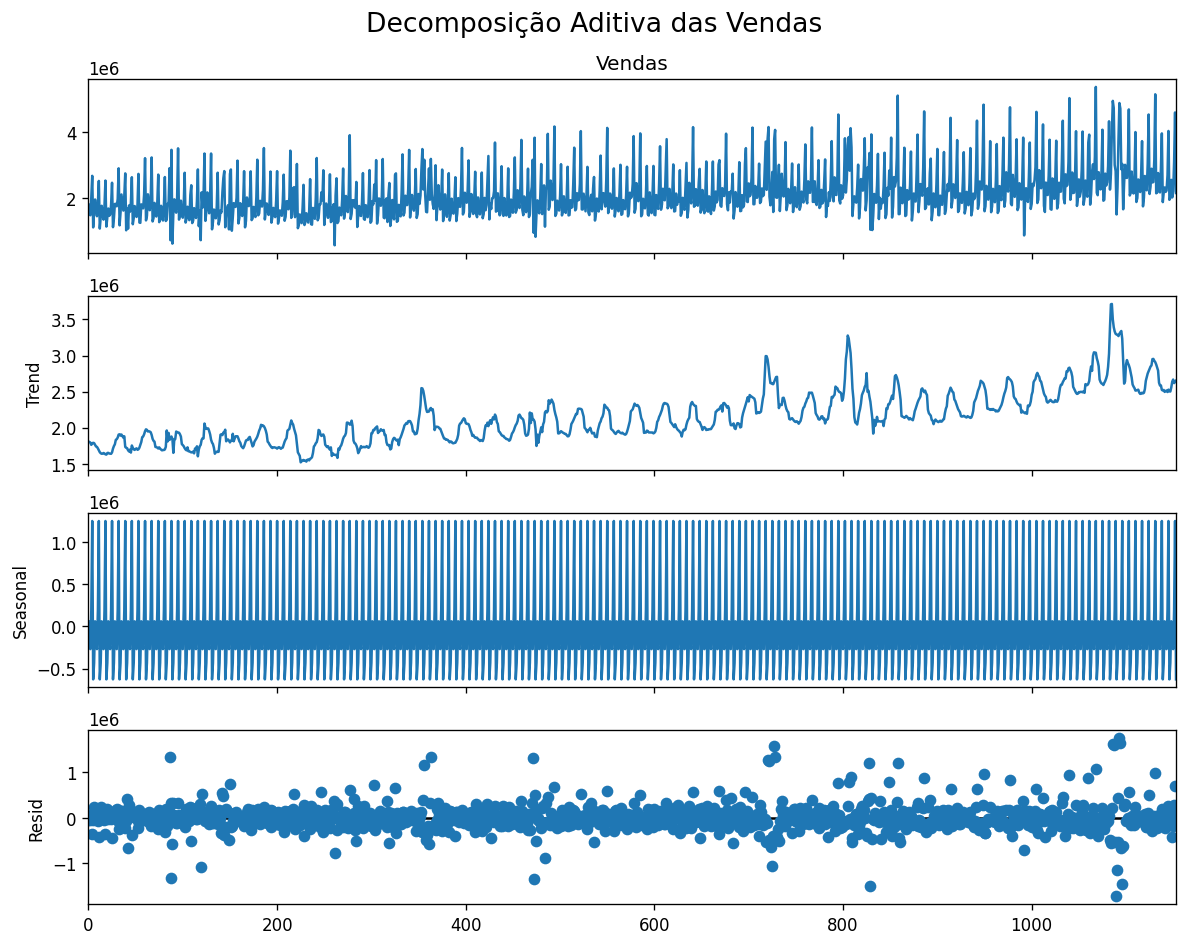

In [26]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

result_mul = seasonal_decompose(
    serie['Vendas'],
    model='additive',
    period=7, # semanal
    extrapolate_trend='freq'
)

plt.rcParams.update({'figure.figsize': (10,8)})

result_mul.plot()

plt.suptitle(
    'Decomposição Aditiva das Vendas',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [27]:
serie['Vendas'].isna().sum()

np.int64(0)

A decomposição aditiva revelou uma tendência crescente das vendas ao longo do período analisado, acompanhada de um padrão sazonal semanal relativamente estável. O componente sazonal oscila em torno de zero, enquanto os resíduos permanecem centrados próximos de zero, indicando que a decomposição consegue capturar adequadamente parte da estrutura temporal da série. Entretanto, observa-se aumento da amplitude das flutuações ao longo do tempo, sugerindo que a decomposição multiplicativa pode representar melhor o comportamento dos dados.

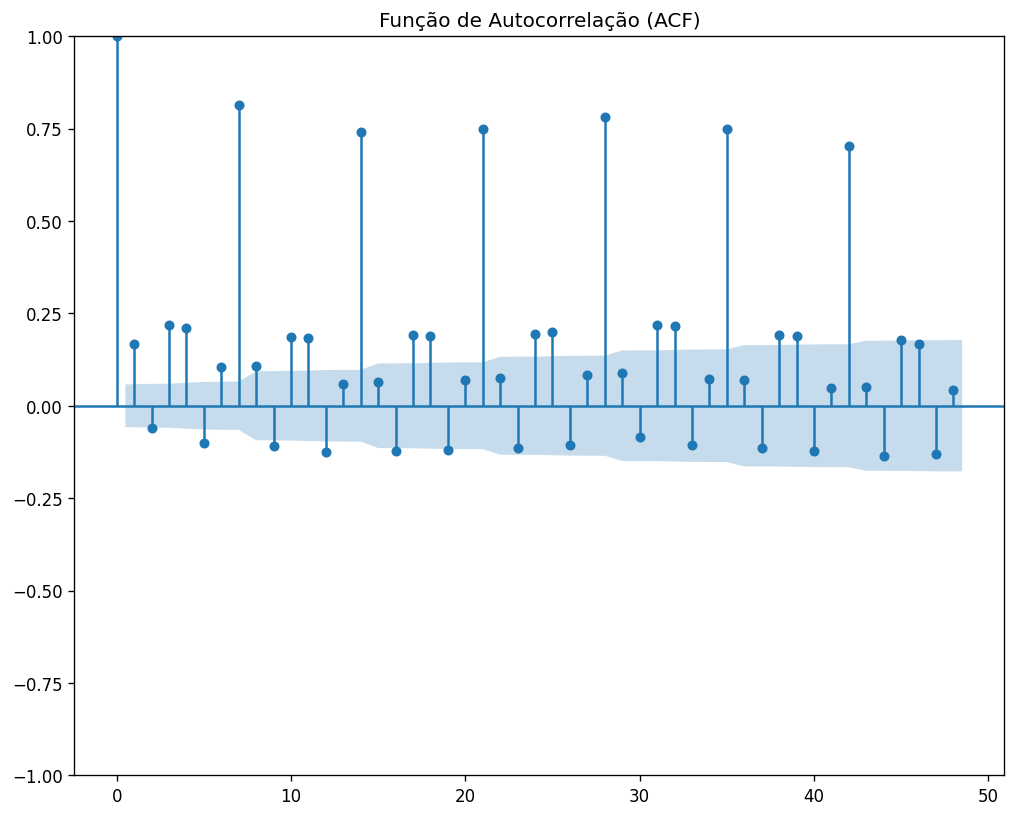

In [28]:
# Verificando autocorrelação
# Usando função ACF

fig = sm.graphics.tsa.plot_acf(serie['Vendas'], lags=48)

plt.title('Função de Autocorrelação (ACF)')
plt.show()

A função de autocorrelação (ACF) evidencia a existência de dependência temporal entre as observações da série de vendas. Observam-se coeficientes de autocorrelação estatisticamente significativos em diversos defasagens, com destaque para os lags múltiplos de sete dias (7, 14, 21, 28, 35 e 42), indicando a presença de sazonalidade semanal. Além disso, a persistência das autocorrelações ao longo das defasagens sugere que a série apresenta comportamento não aleatório, com componentes de tendência e sazonalidade já identificadas na etapa de decomposição.

In [46]:
# Separar treino (2018–2020) e teste (2021)
treino = serie[serie['Ano'] < 2021].copy()
teste = serie[serie['Ano'] == 2021].copy()

print("Tamanho treino:", treino.shape)
print("Tamanho teste:", teste.shape)

Tamanho treino: (1095, 6)
Tamanho teste: (59, 6)


## **RUÍDO BRANCO:**

In [47]:
# Verificando se a série é um Ruído Branco

from statsmodels.stats.diagnostic import acorr_ljungbox

# H0: a série é um ruído branco
# H1: a série não é um ruído branco

lb = acorr_ljungbox(treino['Vendas'], lags=[5], return_df=True)

print(lb)

pvalor = lb['lb_pvalue'].iloc[0]

print('\n========================')
print('Teste de Ljung-Box')
print('========================')

print(f'Estatística: {lb["lb_stat"].iloc[0]:.4f}')
print(f'p-valor: {pvalor:.4e}')

if pvalor < 0.05:
    print('\nConclusão: rejeita-se H0.')
    print('A série NÃO é um ruído branco.')
else:
    print('\nConclusão: não se rejeita H0.')
    print('A série pode ser considerada um ruído branco.')

      lb_stat     lb_pvalue
5  138.795611  3.225902e-28

Teste de Ljung-Box
Estatística: 138.7956
p-valor: 3.2259e-28

Conclusão: rejeita-se H0.
A série NÃO é um ruído branco.


## **ESTACIONARIDADE:**

In [48]:
# Verificando se a série é estacionária

from statsmodels.tsa.stattools import adfuller, kpss

# Teste ADF

print('========================')
print('Teste ADF')
print('========================')

adf = adfuller(treino['Vendas'], autolag='AIC')

print(f'ADF Statistic: {adf[0]}')
print(f'p-value: {adf[1]}')

print('\nValores críticos:')
for key, value in adf[4].items():
    print(f'{key}: {value}')

if adf[1] < 0.05:
    print('\nConclusão: rejeita-se H0.')
    print('A série é estacionária.')
else:
    print('\nConclusão: não se rejeita H0.')
    print('A série não é estacionária.')

Teste ADF
ADF Statistic: -1.3867474074951218
p-value: 0.5886128295981373

Valores críticos:
1%: -3.436459052172655
5%: -2.864237372528562
10%: -2.568206176974609

Conclusão: não se rejeita H0.
A série não é estacionária.


## **ALISAMENTO EXPONENCIAL:**



**1. Simples: Simple Exponential Smoothing (SES)**

In [49]:
print(type(serie))
print(treino.dtypes)

<class 'pandas.core.frame.DataFrame'>
Data_BR      datetime64[ns]
Vendas              float64
Ano                   int32
Mes                   int32
DiaSemana             int32
Imputado               bool
dtype: object


MAE: 631,475
RMSE: 785,521
MAPE: 24.48%


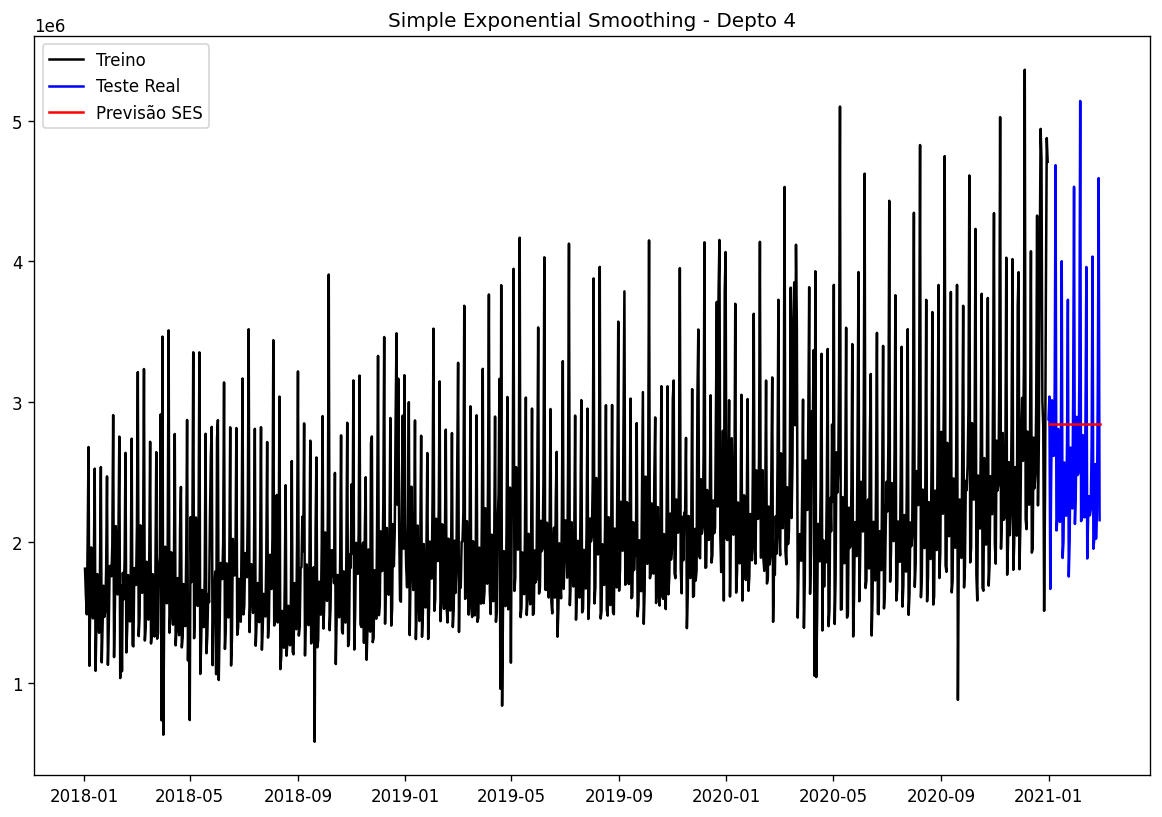

In [50]:
# Ajustar modelo no treino
fit1 = SimpleExpSmoothing(treino['Vendas'], initialization_method="estimated").fit()

# Previsão para o tamanho do teste
fcast1 = fit1.forecast(len(teste))

# Comparar com valores reais
resultado = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast1
})

# Métricas de erro
mae = mean_absolute_error(resultado['Real'], resultado['Previsto'])
rmse = np.sqrt(mean_squared_error(resultado['Real'], resultado['Previsto']))
mape = mean_absolute_percentage_error(resultado['Real'], resultado['Previsto'])

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAPE: {mape:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast1, color='red', label='Previsão SES')
plt.title('Simple Exponential Smoothing - Depto 4')
plt.legend()
plt.show()

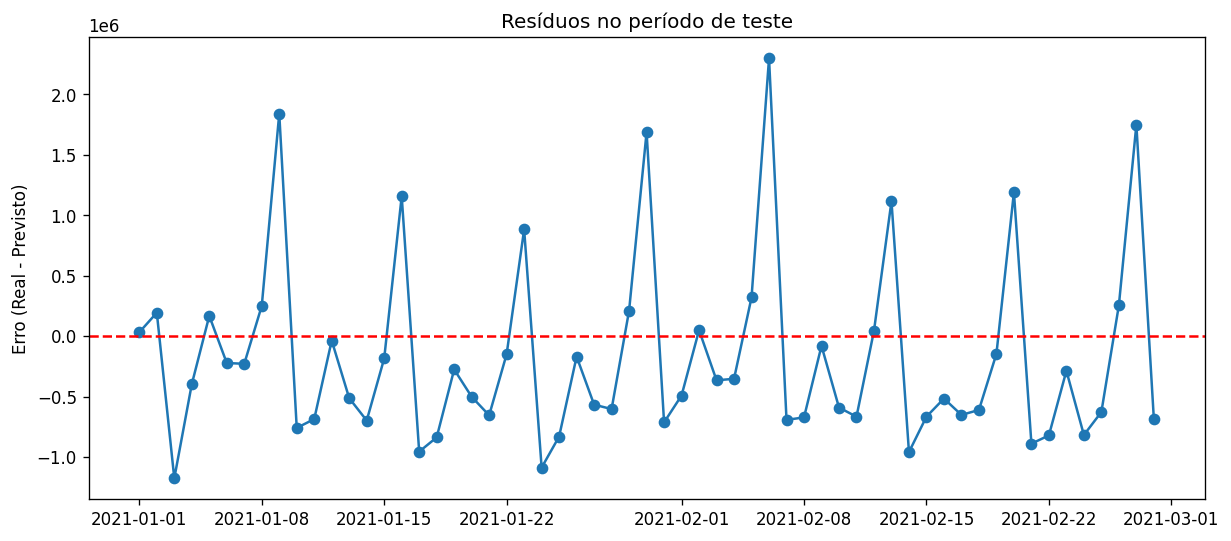

In [61]:
erro = teste['Vendas'].values - fcast1.values

plt.figure(figsize=(12,5))
plt.plot(teste['Data_BR'], erro, marker='o')
plt.axhline(0, color='red', linestyle='--')

plt.title('Resíduos no período de teste')
plt.ylabel('Erro (Real - Previsto)')
plt.show()

In [67]:
# Resíduos do modelo SES
residuos_ses = fit1.resid

# Teste de Ljung-Box até 20 defasagens
ljung_ses = acorr_ljungbox(residuos_ses, lags=[7, 14, 21], return_df=True)

print("Teste de Ljung-Box - SES")
for lag, row in ljung_ses.iterrows():
    pvalor = row['lb_pvalue']
    if pvalor > 0.05:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
    else:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")

Teste de Ljung-Box - SES
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)


**2. HOLT SEM TENDÊNCIA AMORTECIDA**

MAE Holt: 829,639
RMSE Holt: 935,464
MAPE Holt: 34.47%


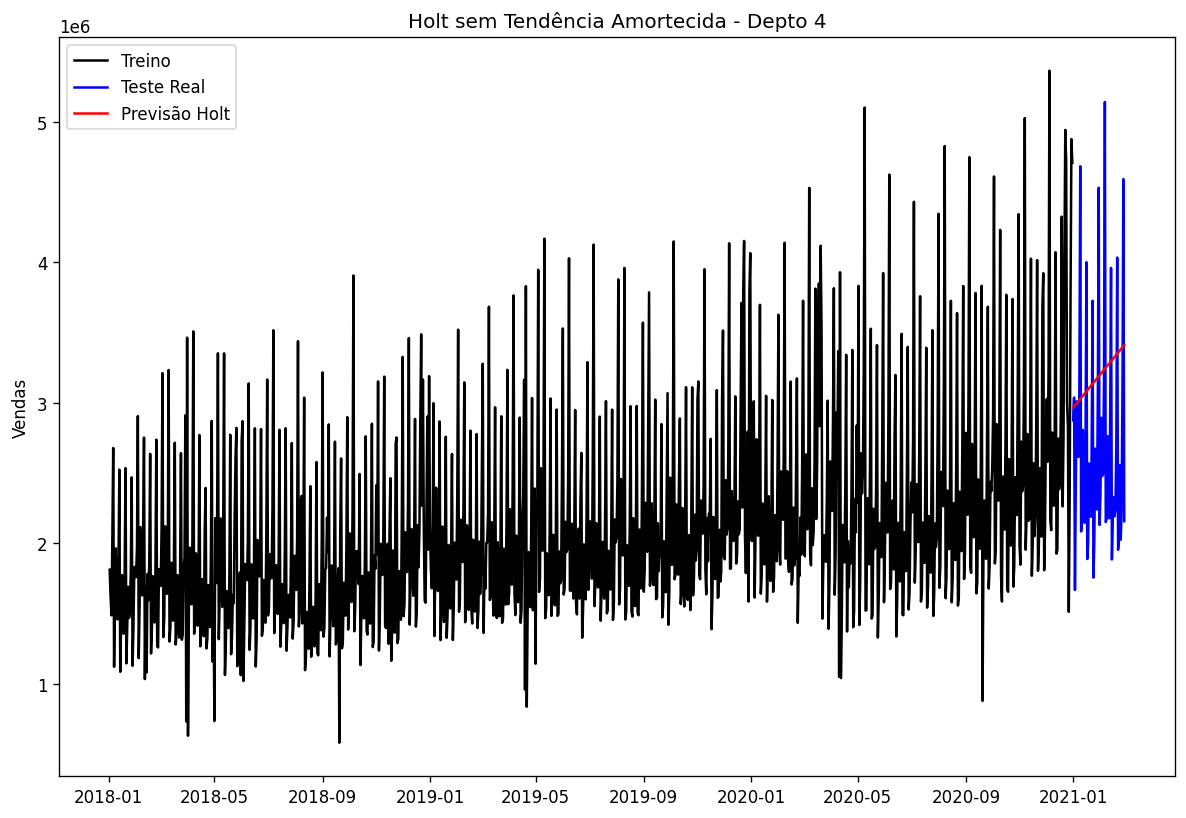

In [51]:
# Ajustar modelo Holt (sem tendência amortecida)
fit1_ht = Holt(treino['Vendas'], damped_trend=False, initialization_method="estimated").fit()

# Previsão para o tamanho do teste
fcast1_ht = fit1_ht.forecast(len(teste))
fcast1_ht = fcast1_ht.rename("Previsão Holt")

# Comparar com valores reais
resultado_ht = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast1_ht
})

# Métricas de erro
mae_ht = mean_absolute_error(resultado_ht['Real'], resultado_ht['Previsto'])
rmse_ht = np.sqrt(mean_squared_error(resultado_ht['Real'], resultado_ht['Previsto']))
mape_ht = mean_absolute_percentage_error(resultado_ht['Real'], resultado_ht['Previsto'])

print(f"MAE Holt: {mae_ht:,.0f}")
print(f"RMSE Holt: {rmse_ht:,.0f}")
print(f"MAPE Holt: {mape_ht:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast1_ht, color='red', label='Previsão Holt')
plt.title('Holt sem Tendência Amortecida - Depto 4')
plt.ylabel('Vendas')
plt.legend()
plt.show()

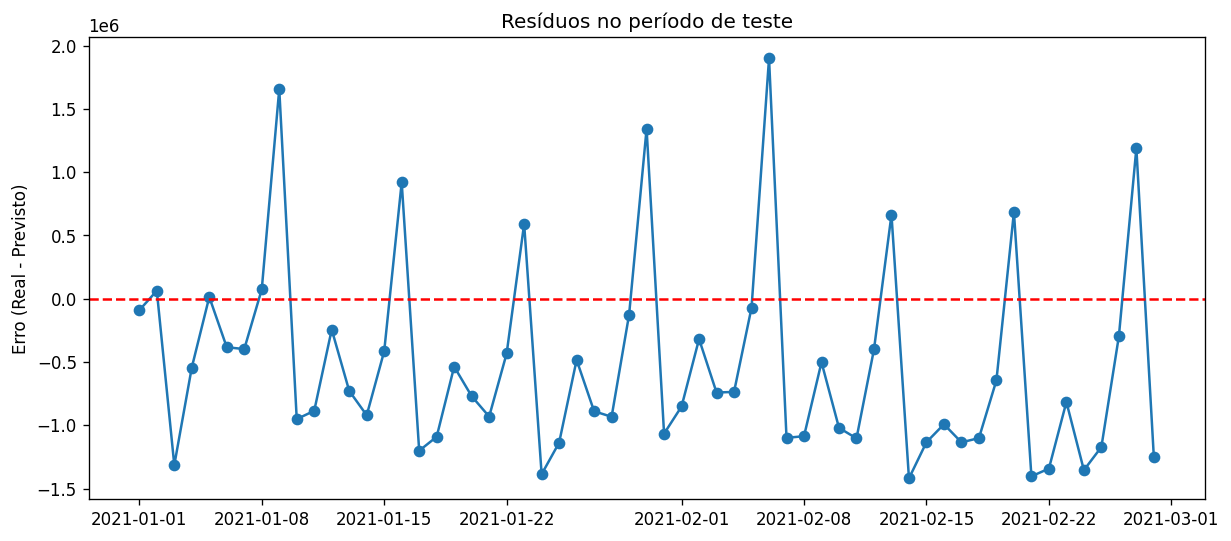

In [60]:
erro = teste['Vendas'].values - fcast1_ht.values

plt.figure(figsize=(12,5))
plt.plot(teste['Data_BR'], erro, marker='o')
plt.axhline(0, color='red', linestyle='--')

plt.title('Resíduos no período de teste')
plt.ylabel('Erro (Real - Previsto)')
plt.show()

In [70]:
# Resíduos do modelo Holt sem Tendência Amortecida
residuos_holt = fit1_ht.resid

# Teste de Ljung-Box até 20 defasagens
ljung_holt = acorr_ljungbox(residuos_holt, lags=[7, 14, 21], return_df=True)

print("Teste de Ljung-Box - Holt sem Tendência Amortecida")
for lag, row in ljung_holt.iterrows():
    pvalor = row['lb_pvalue']
    if pvalor > 0.05:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
    else:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")

Teste de Ljung-Box - Holt sem Tendência Amortecida
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)


**3. HOLT COM TENDÊNCIA AMORTECIDA (Damped Trend)**

MAE Holt Amortecido: 739,793
RMSE Holt Amortecido: 858,555
MAPE Holt Amortecido: 30.10%


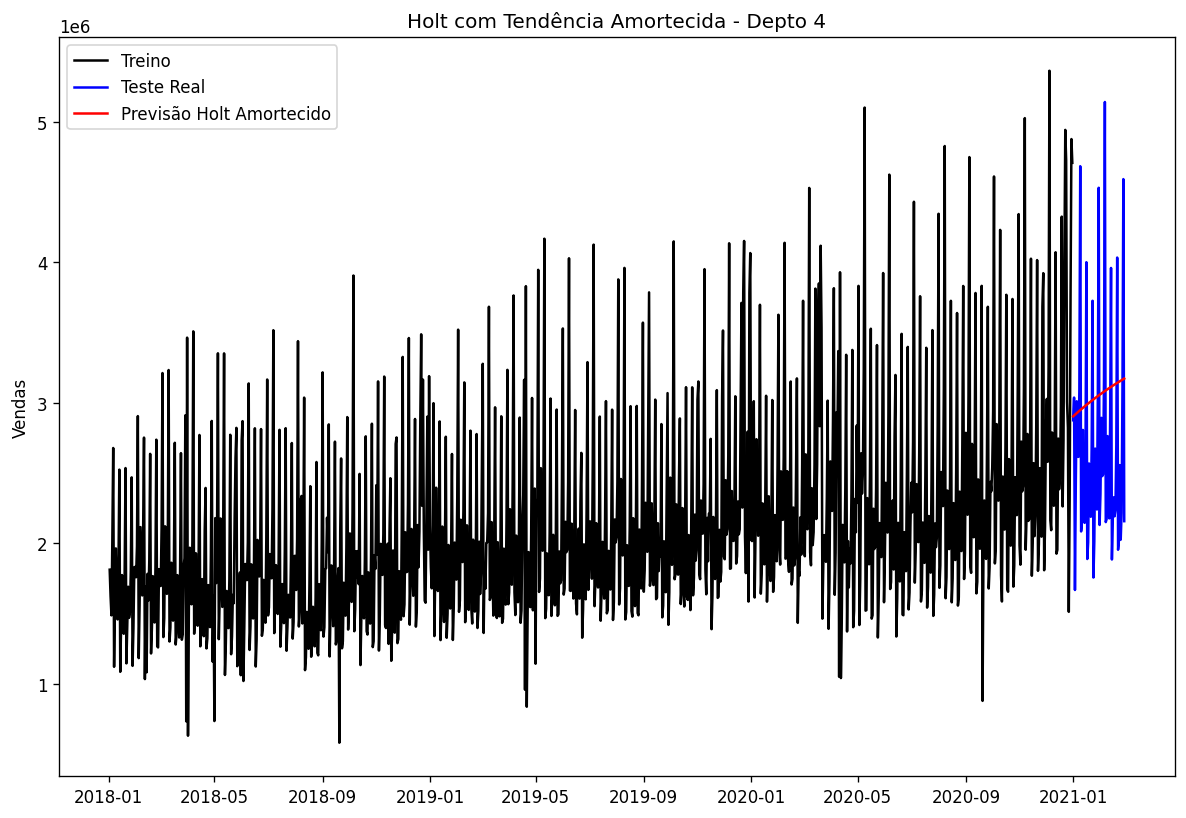

In [103]:
# Ajustar modelo Holt com tendência amortecida
fit2_ht = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit()

# Previsão para o tamanho do teste
fcast2_ht = fit2_ht.forecast(len(teste))
fcast2_ht = fcast2_ht.rename("Previsão Holt Amortecido")

# Comparar com valores reais
resultado_ht2 = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast2_ht
})

# Métricas de erro
mae_ht2 = mean_absolute_error(resultado_ht2['Real'], resultado_ht2['Previsto'])
rmse_ht2 = np.sqrt(mean_squared_error(resultado_ht2['Real'], resultado_ht2['Previsto']))
mape_ht2 = mean_absolute_percentage_error(resultado_ht2['Real'], resultado_ht2['Previsto'])

print(f"MAE Holt Amortecido: {mae_ht2:,.0f}")
print(f"RMSE Holt Amortecido: {rmse_ht2:,.0f}")
print(f"MAPE Holt Amortecido: {mape_ht2:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast2_ht, color='red', label='Previsão Holt Amortecido')
plt.title('Holt com Tendência Amortecida - Depto 4')
plt.ylabel('Vendas')
plt.legend()
plt.show()

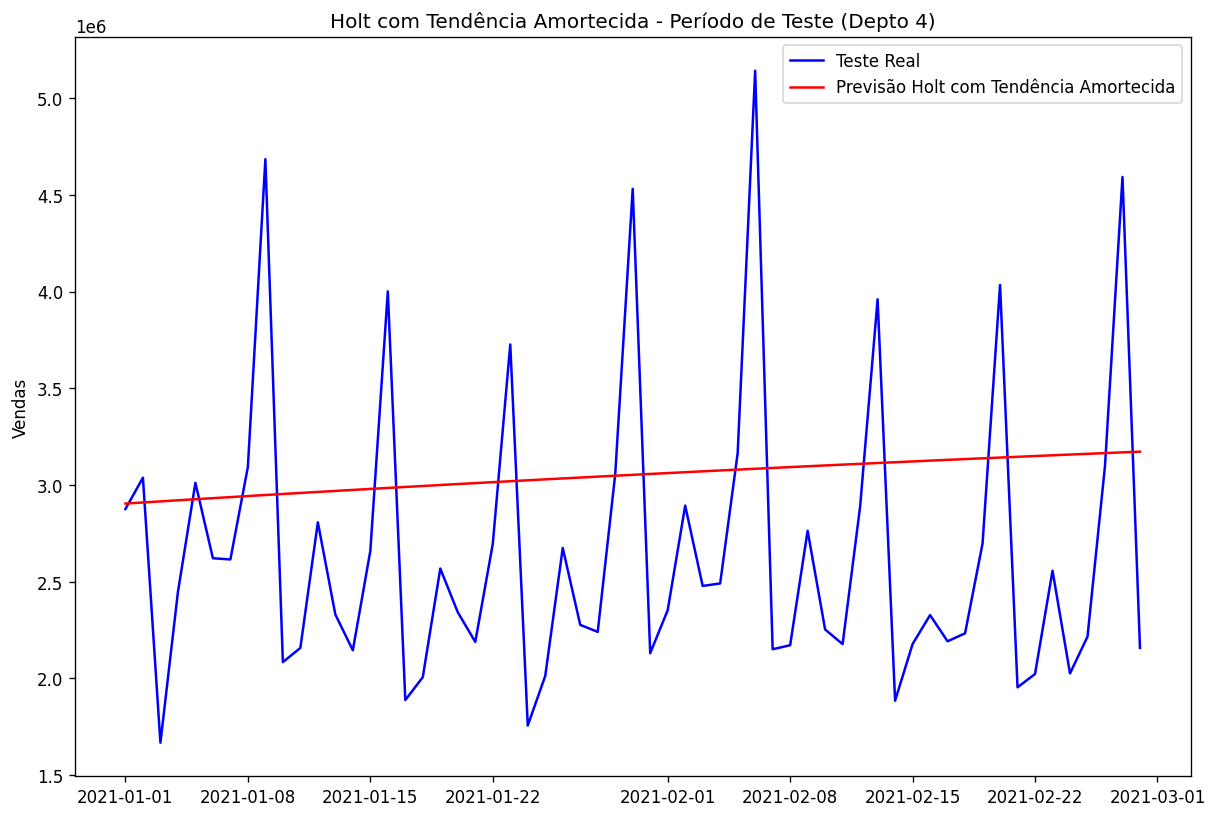

In [105]:
# Gerar previsão para o período de teste
fcast_ht = fit2_ht.forecast(len(teste))

# Plotar apenas o período de teste
plt.figure(figsize=(12,8))
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast_ht, color='red', label='Previsão Holt com Tendência Amortecida')
plt.title('Holt com Tendência Amortecida - Período de Teste (Depto 4)')
plt.ylabel('Vendas')
plt.legend()
plt.show()

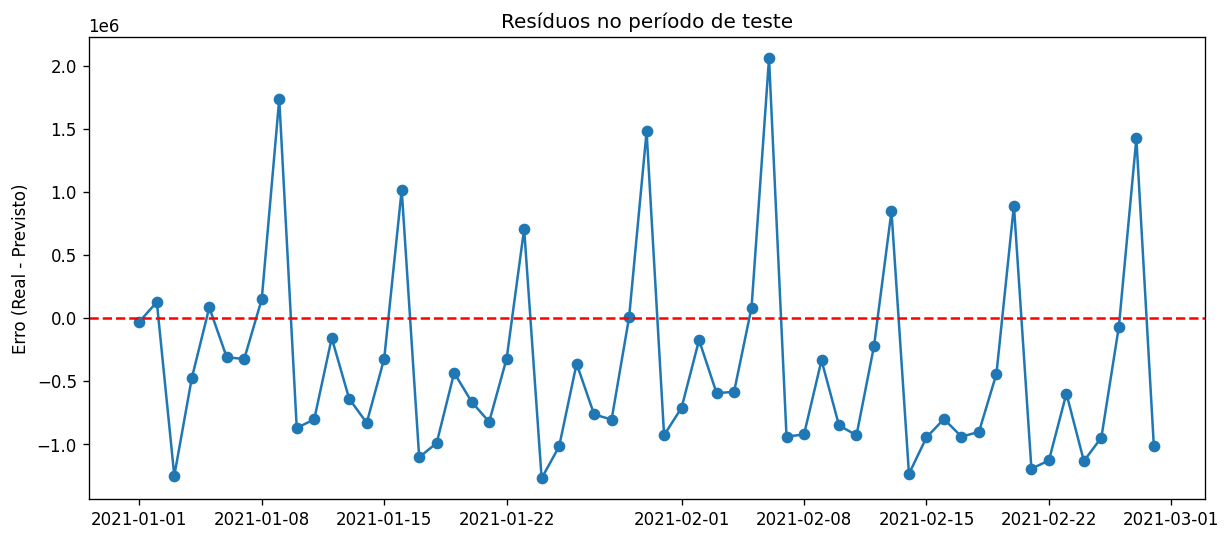

In [59]:
erro = teste['Vendas'].values - fcast2_ht.values

plt.figure(figsize=(12,5))
plt.plot(teste['Data_BR'], erro, marker='o')
plt.axhline(0, color='red', linestyle='--')

plt.title('Resíduos no período de teste')
plt.ylabel('Erro (Real - Previsto)')
plt.show()

In [71]:
# Resíduos do modelo Holt sem Tendência Amortecida
residuos_holt2 = fit2_ht.resid

# Teste de Ljung-Box até 20 defasagens
ljung_holt2 = acorr_ljungbox(residuos_holt2, lags=[7, 14, 21], return_df=True)

print("Teste de Ljung-Box - Holt com Tendência Amortecida")
for lag, row in ljung_holt2.iterrows():
    pvalor = row['lb_pvalue']
    if pvalor > 0.05:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
    else:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")

Teste de Ljung-Box - Holt com Tendência Amortecida
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)


In [53]:
# Ajustar modelos
fit1 = SimpleExpSmoothing(treino['Vendas'], initialization_method="estimated").fit()
fit2 = Holt(treino['Vendas'], initialization_method="estimated").fit()
fit3 = Holt(treino['Vendas'], exponential=True, initialization_method="estimated").fit()
fit4 = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fit5 = Holt(treino['Vendas'], exponential=True, damped_trend=True, initialization_method="estimated").fit()

# Previsões para o teste
models = {
    "SES": fit1.forecast(len(teste)),
    "Holt's": fit2.forecast(len(teste)),
    "Exponential": fit3.forecast(len(teste)),
    "Additive": fit4.forecast(len(teste)),
    "Multiplicative": fit5.forecast(len(teste))
}

# Calcular métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

results = []
for name, forecast in models.items():
    mae = mean_absolute_error(teste['Vendas'], forecast)
    rmse = np.sqrt(mean_squared_error(teste['Vendas'], forecast))
    mape = mean_absolute_percentage_error(teste['Vendas'], forecast)
    results.append([name, mae, rmse, mape])

# Tabela final
df_results = pd.DataFrame(results, columns=["Modelo", "MAE", "RMSE", "MAPE"])
print(df_results)

           Modelo            MAE           RMSE      MAPE
0             SES  631475.299127  785520.561513  0.244798
1          Holt's  829638.823654  935464.112327  0.344705
2     Exponential  869822.711763  974500.239705  0.363957
3        Additive  692266.847307  821994.055977  0.276835
4  Multiplicative  752099.056835  868427.841182  0.307082


Apesar de a série apresentar visualmente um leve crescimento, o parâmetro de tendência estimado pelo modelo de Holt foi praticamente nulo (β ≈ 0), indicando que a inclusão de uma componente de tendência não trouxe ganho significativo ao ajuste. O modelo Holt apresentou o menor valor de SSE, porém seu comportamento é bastante semelhante ao da Suavização Exponencial Simples.


*  O SES (Simple Exponential Smoothing) foi o mais eficaz, com menor MAPE e erros absolutos mais baixos;

*  Os modelos Holt (simples, exponencial e amortecidos) não superaram o SES, sugerindo que a série tem padrão estacionário com sazonalidade curta, e não uma tendência forte.

*  Isso confirma o que foi observado na decomposição: oscilações semanais e crescimento moderado, mas sem tendência linear clara.

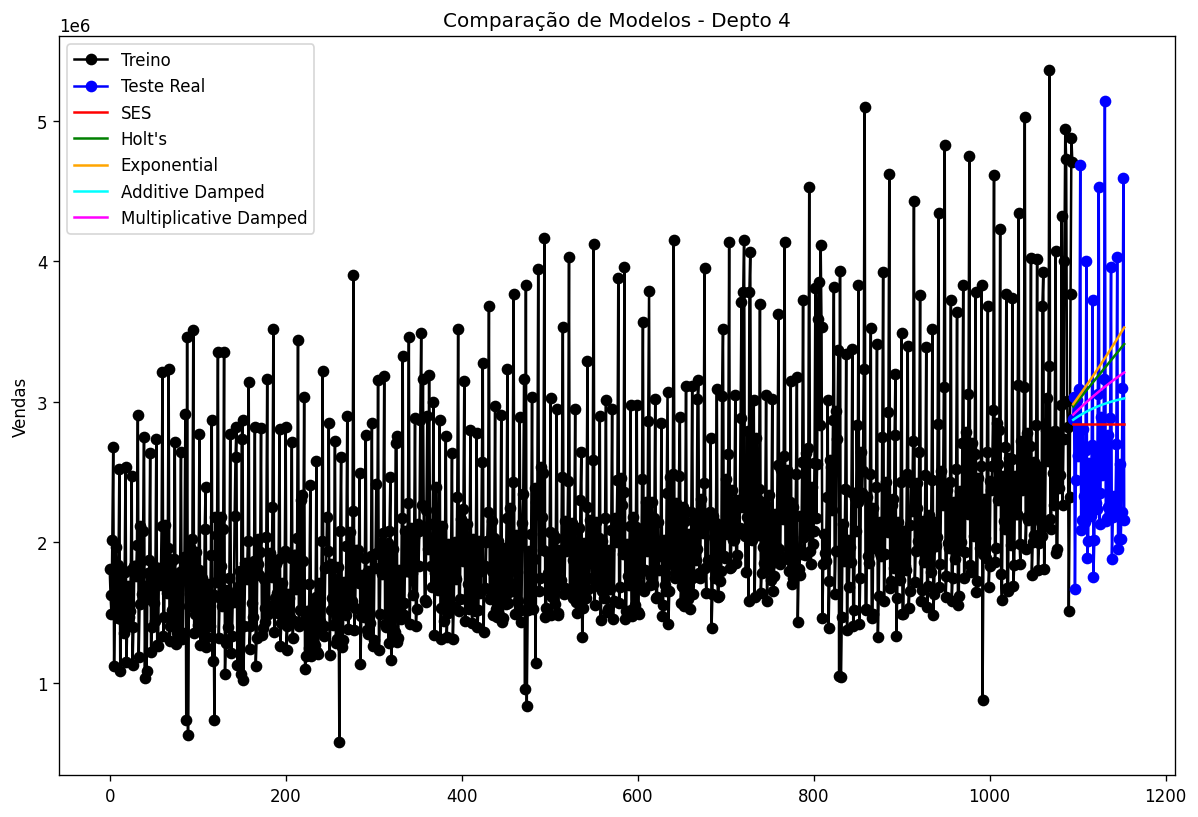

In [54]:
# Ajustar modelos
fit1 = SimpleExpSmoothing(treino['Vendas'], initialization_method="estimated").fit()
fit2 = Holt(treino['Vendas'], initialization_method="estimated").fit()
fit3 = Holt(treino['Vendas'], exponential=True, initialization_method="estimated").fit()
fit4 = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fit5 = Holt(treino['Vendas'], exponential=True, damped_trend=True, initialization_method="estimated").fit()

# Previsões para o período de teste
fcast1 = fit1.forecast(len(teste)).rename("SES")
fcast2 = fit2.forecast(len(teste)).rename("Holt's")
fcast3 = fit3.forecast(len(teste)).rename("Exponential")
fcast4 = fit4.forecast(len(teste)).rename("Additive Damped")
fcast5 = fit5.forecast(len(teste)).rename("Multiplicative Damped")

# Plotando
ax = treino['Vendas'].plot(color="black", marker="o", figsize=(12,8), label="Treino")
teste['Vendas'].plot(ax=ax, color="blue", marker="o", label="Teste Real")
fcast1.plot(ax=ax, color='red', legend=True)
fcast2.plot(ax=ax, color='green', legend=True)
fcast3.plot(ax=ax, color='orange', legend=True)
fcast4.plot(ax=ax, color='cyan', legend=True)
fcast5.plot(ax=ax, color='magenta', legend=True)
ax.set_ylabel('Vendas')
plt.title('Comparação de Modelos - Depto 4')
plt.legend()
plt.show()

**4. HOLT - WINTERS (NÍVEL, TENDÊNCIA E SAZONALIDADE)**

MAE Holt-Winters: 1,509,036
RMSE Holt-Winters: 1,711,079
MAPE Holt-Winters: 55.63%


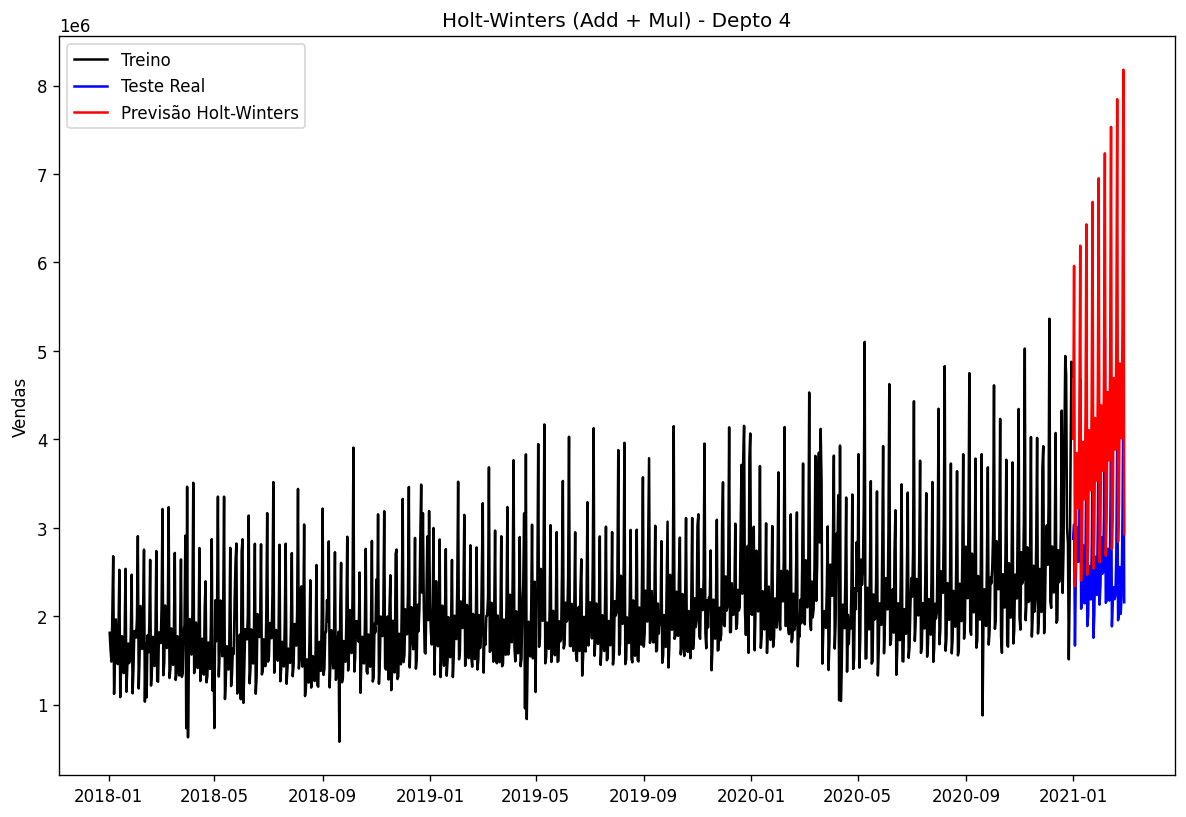

In [55]:
# Ajustar Holt-Winters (tendência aditiva + sazonalidade multiplicativa)
fit_hw = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,   # padrão semanal
    trend='add',
    seasonal='mul',
    use_boxcox=True,      #estabilizar a variância dos dados, contribuindo para um melhor ajuste do modelo.
    initialization_method="estimated"
).fit()

# Previsão para o período de teste
fcast_hw = fit_hw.forecast(len(teste)).rename("Holt-Winters Multiplicativo")

# Comparar com valores reais
resultado_hw = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast_hw
})

# Métricas de erro
mae_hw = mean_absolute_error(resultado_hw['Real'], resultado_hw['Previsto'])
rmse_hw = np.sqrt(mean_squared_error(resultado_hw['Real'], resultado_hw['Previsto']))
mape_hw = mean_absolute_percentage_error(resultado_hw['Real'], resultado_hw['Previsto'])

print(f"MAE Holt-Winters: {mae_hw:,.0f}")
print(f"RMSE Holt-Winters: {rmse_hw:,.0f}")
print(f"MAPE Holt-Winters: {mape_hw:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast_hw, color='red', label='Previsão Holt-Winters')
plt.title('Holt-Winters (Add + Mul) - Depto 4')
plt.ylabel('Vendas')
plt.legend()
plt.show()

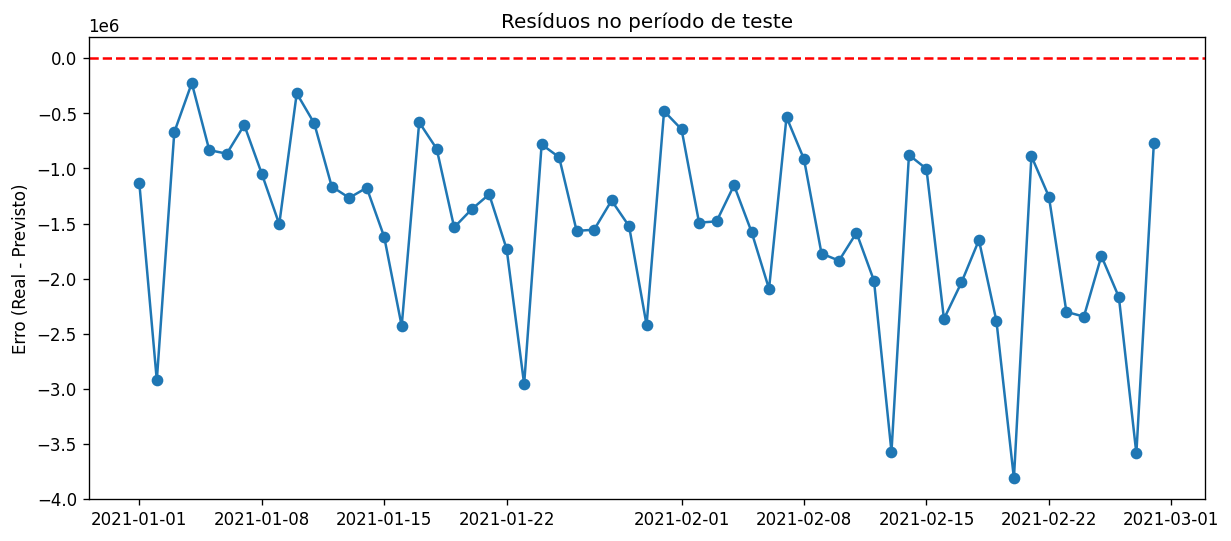

In [58]:
erro = teste['Vendas'].values - fcast_hw.values

plt.figure(figsize=(12,5))
plt.plot(teste['Data_BR'], erro, marker='o')
plt.axhline(0, color='red', linestyle='--')

plt.title('Resíduos no período de teste')
plt.ylabel('Erro (Real - Previsto)')
plt.show()

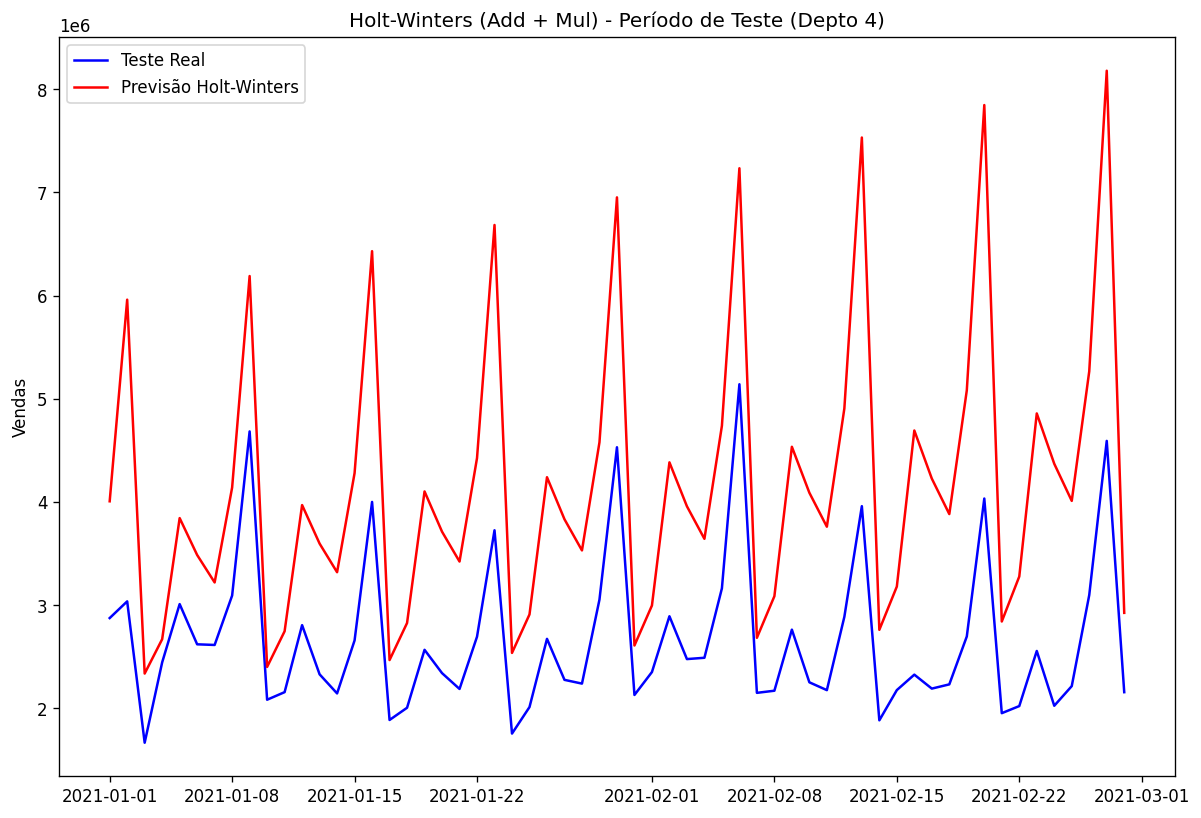

In [99]:
# Plotando apenas o período de teste
plt.figure(figsize=(12,8))
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast_hw, color='red', label='Previsão Holt-Winters')
plt.title('Holt-Winters (Add + Mul) - Período de Teste (Depto 4)')
plt.ylabel('Vendas')
plt.legend()
plt.show()

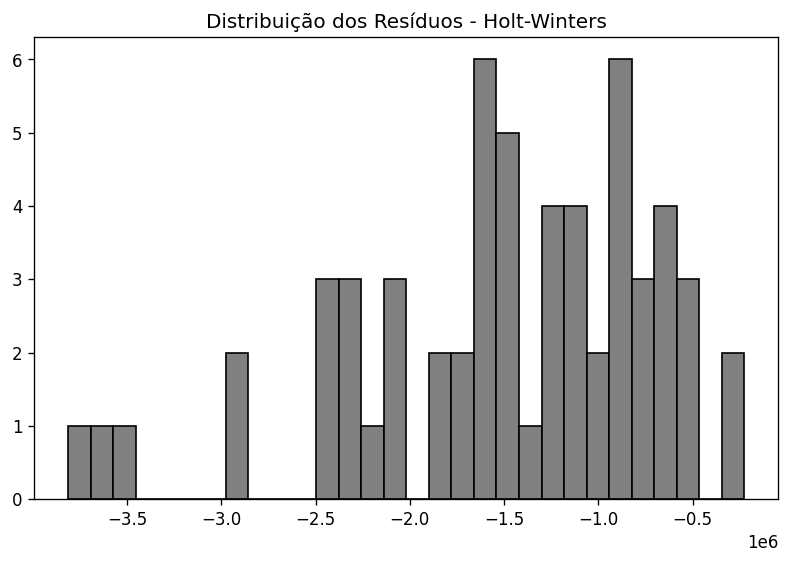

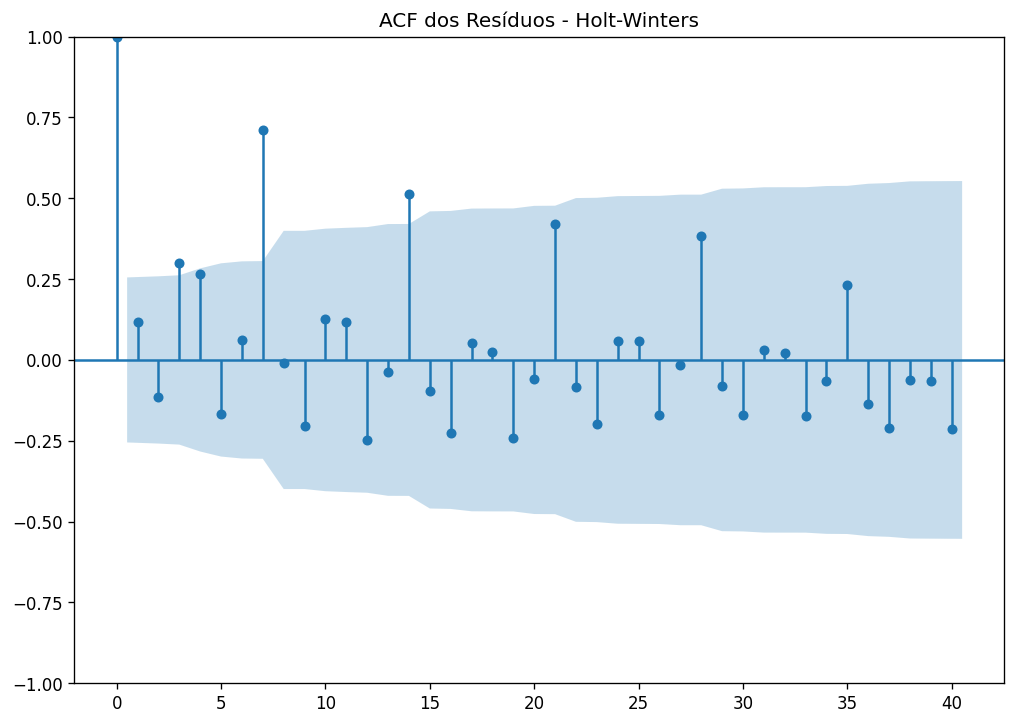

Teste de Ljung-Box - Holt-Winters
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)


In [101]:
# Resíduos = valores reais - previstos
erro = teste['Vendas'].values - fcast_hw.values

# Histograma dos resíduos
plt.figure(figsize=(8,5))
plt.hist(erro, bins=30, color='gray', edgecolor='black')
plt.title("Distribuição dos Resíduos - Holt-Winters")
plt.show()

# ACF dos resíduos
sm.graphics.tsa.plot_acf(erro, lags=40)
plt.title("ACF dos Resíduos - Holt-Winters")
plt.show()

# Teste de Ljung-Box em múltiplos da sazonalidade semanal
ljung_hw = acorr_ljungbox(erro, lags=[7, 14, 21], return_df=True)

print("Teste de Ljung-Box - Holt-Winters")
for lag, row in ljung_hw.iterrows():
    pvalor = row['lb_pvalue']
    if pvalor > 0.05:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
    else:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")

In [ ]:
# Ajustar Holt-Winters (tendência aditiva + sazonalidade multiplicativa)
fit_hw2 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,   # padrão semanal
    trend='add',
    seasonal='mul',
    use_boxcox=True,      #estabilizar a variância dos dados, contribuindo para um melhor ajuste do modelo.
    initialization_method="estimated"
).fit()

fit4 = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)

# Previsão para o período de teste
fcast_hw = fit_hw.forecast(len(teste)).rename("Holt-Winters Multiplicativo")

# Comparar com valores reais
resultado_hw = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast_hw
})

# Métricas de erro
mae_hw = mean_absolute_error(resultado_hw['Real'], resultado_hw['Previsto'])
rmse_hw = np.sqrt(mean_squared_error(resultado_hw['Real'], resultado_hw['Previsto']))
mape_hw = mean_absolute_percentage_error(resultado_hw['Real'], resultado_hw['Previsto'])

print(f"MAE Holt-Winters: {mae_hw:,.0f}")
print(f"RMSE Holt-Winters: {rmse_hw:,.0f}")
print(f"MAPE Holt-Winters: {mape_hw:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast_hw, color='red', label='Previsão Holt-Winters')
plt.title('Holt-Winters (Add + Mul) - Depto 4')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [56]:
print(fit_hw.summary())

                        ExponentialSmoothing Model Results                       
Dep. Variable:                   Vendas   No. Observations:                  1095
Model:             ExponentialSmoothing   SSE                 140060207882358.203
Optimized:                         True   AIC                           28026.169
Trend:                         Additive   BIC                           28081.153
Seasonal:                Multiplicative   AICC                          28026.506
Seasonal Periods:                     7   Date:                  Mon, 06 Jul 2026
Box-Cox:                           True   Time:                          22:52:10
Box-Cox Coeff.:                -0.34849                                          
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1464227                alpha                 True
smoothing_trend 

**5. COMPARANDO MODELOS**

Métricas de Erro por Modelo:
                  Modelo         MAE        RMSE    MAPE
0                    SES   631475.30   785520.56  0.2448
1                 Holt's   829638.82   935464.11  0.3447
2            Exponential   869822.71   974500.24  0.3640
3        Additive Damped   692266.85   821994.06  0.2768
4  Multiplicative Damped   752099.06   868427.84  0.3071
5             HW Add+Mul  1509036.02  1711078.81  0.5563
6             HW Mul+Add  1321299.96  1359888.05  0.5373
7             HW Add+Add  1339829.95  1378015.33  0.5447
8             HW Mul+Mul  1664332.82  1751111.90  0.6349

Parâmetros Principais dos Modelos:
                         SES    Holt's  Exponential  Additive Damped  \
smoothing_level     0.022725  0.020413     0.020493         0.018873   
smoothing_trend          NaN  0.020413     0.020493         0.018873   
smoothing_seasonal       NaN       NaN          NaN              NaN   
damping_trend            NaN       NaN          NaN         0.980000   

    

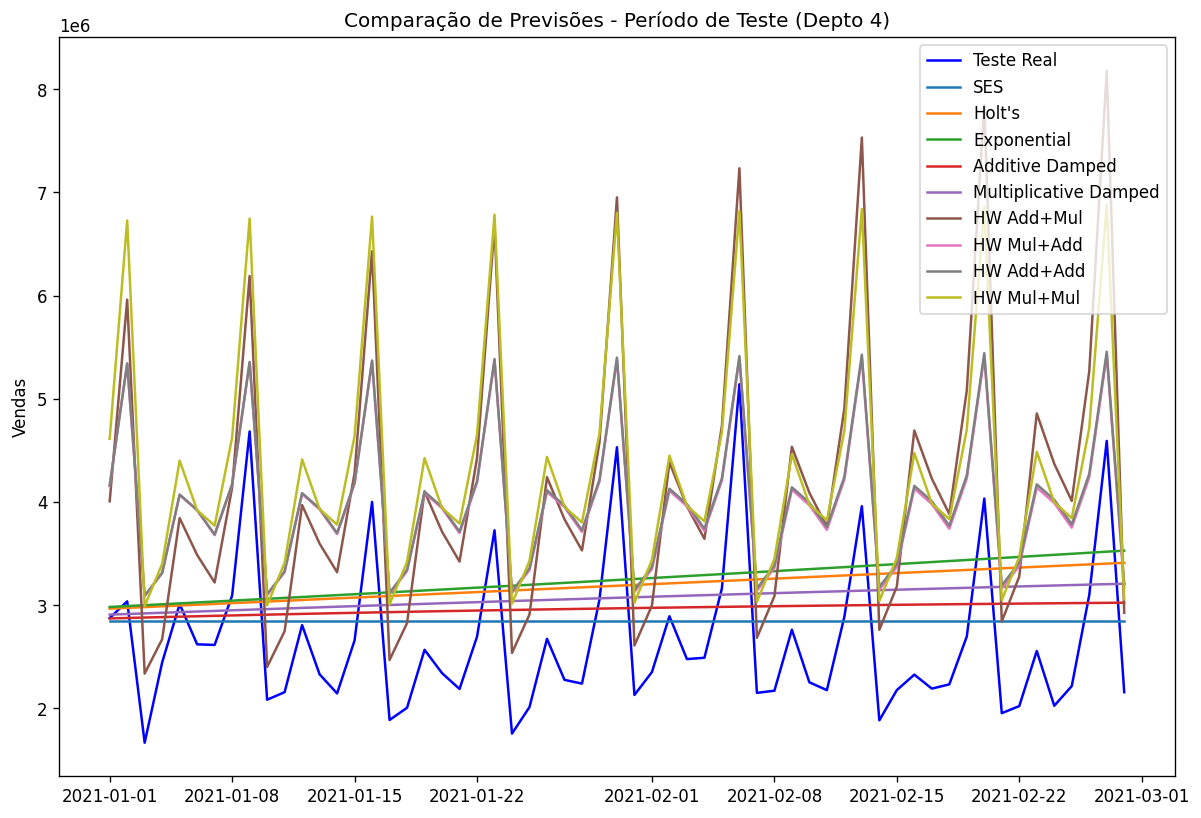

In [107]:
# SES - Suavização Exponencial Simples
fit1 = SimpleExpSmoothing(treino['Vendas'], initialization_method="estimated").fit()

# Holt - Tendência aditiva
fit2 = Holt(treino['Vendas'], initialization_method="estimated").fit()

# Holt Exponencial - Tendência multiplicativa
fit3 = Holt(treino['Vendas'], exponential=True, initialization_method="estimated").fit()

# Holt Amortecido - Tendência aditiva amortecida
fit4 = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)

# Holt Exponencial Amortecido
fit5 = Holt(treino['Vendas'], exponential=True, damped_trend=True, initialization_method="estimated").fit()

# Holt-Winters - Tendência aditiva + sazonalidade multiplicativa
fit6 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,   # padrão semanal
    trend='add',
    seasonal='mul',
    use_boxcox=True,
    initialization_method="estimated"
).fit()

# Holt-Winters - Tendência multiplicativa + sazonalidade aditiva
fit7 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,
    trend='mul',
    seasonal='add',
    initialization_method="estimated"
).fit()

# Holt-Winters - Tendência aditiva + sazonalidade aditiva
fit8 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,
    trend='add',
    seasonal='add',
    initialization_method="estimated"
).fit()

# Holt-Winters - Tendência multiplicativa + sazonalidade multiplicativa
fit9 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,
    trend='mul',
    seasonal='mul',
    initialization_method="estimated"
).fit()

# Previsões
models = {
    "SES": fit1.forecast(len(teste)),
    "Holt's": fit2.forecast(len(teste)),
    "Exponential": fit3.forecast(len(teste)),
    "Additive Damped": fit4.forecast(len(teste)),
    "Multiplicative Damped": fit5.forecast(len(teste)),
    "HW Add+Mul": fit6.forecast(len(teste)),
    "HW Mul+Add": fit7.forecast(len(teste)),
    "HW Add+Add": fit8.forecast(len(teste)),
    "HW Mul+Mul": fit9.forecast(len(teste))
}

# Calcular métricas de erro
results = []
for name, forecast in models.items():
    mae = mean_absolute_error(teste['Vendas'], forecast)
    rmse = np.sqrt(mean_squared_error(teste['Vendas'], forecast))
    mape = mean_absolute_percentage_error(teste['Vendas'], forecast)
    results.append([name, round(mae, 2), round(rmse, 2), round(mape, 4)])

df_results = pd.DataFrame(results, columns=["Modelo", "MAE", "RMSE", "MAPE"])
print("Métricas de Erro por Modelo:")
print(df_results)

# Parâmetros principais
params = ['smoothing_level', 'smoothing_trend', 'smoothing_seasonal', 'damping_trend']

df_params = pd.DataFrame({
    "SES": [fit1.params.get(p, None) for p in params],
    "Holt's": [fit2.params.get(p, None) for p in params],
    "Exponential": [fit3.params.get(p, None) for p in params],
    "Additive Damped": [fit4.params.get(p, None) for p in params],
    "Multiplicative Damped": [fit5.params.get(p, None) for p in params],
    "HW Add+Mul": [fit6.params.get(p, None) for p in params],
    "HW Mul+Add": [fit7.params.get(p, None) for p in params],
    "HW Add+Add": [fit8.params.get(p, None) for p in params],
    "HW Mul+Mul": [fit9.params.get(p, None) for p in params],
}, index=params)

print("\nParâmetros Principais dos Modelos:")
print(df_params)

# Plot comparativo
plt.figure(figsize=(12,8))
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
for name, forecast in models.items():
    plt.plot(teste['Data_BR'], forecast, label=name)
plt.title('Comparação de Previsões - Período de Teste (Depto 4)')
plt.ylabel('Vendas')
plt.legend()
plt.show()


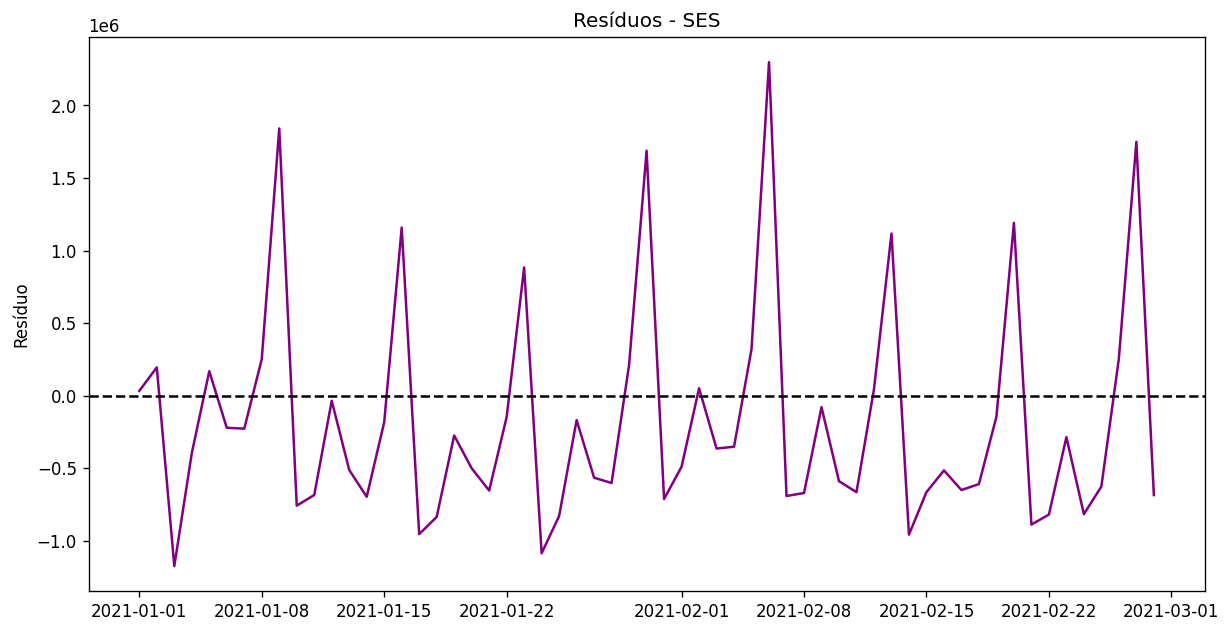

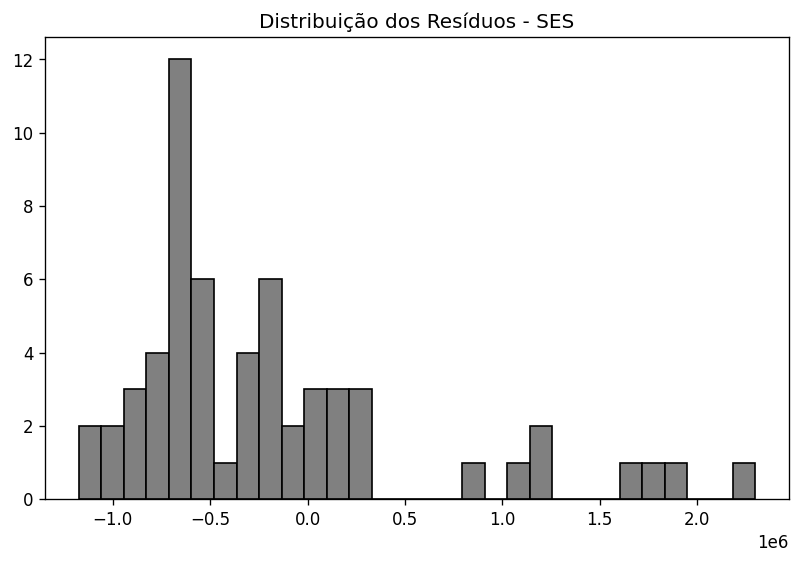

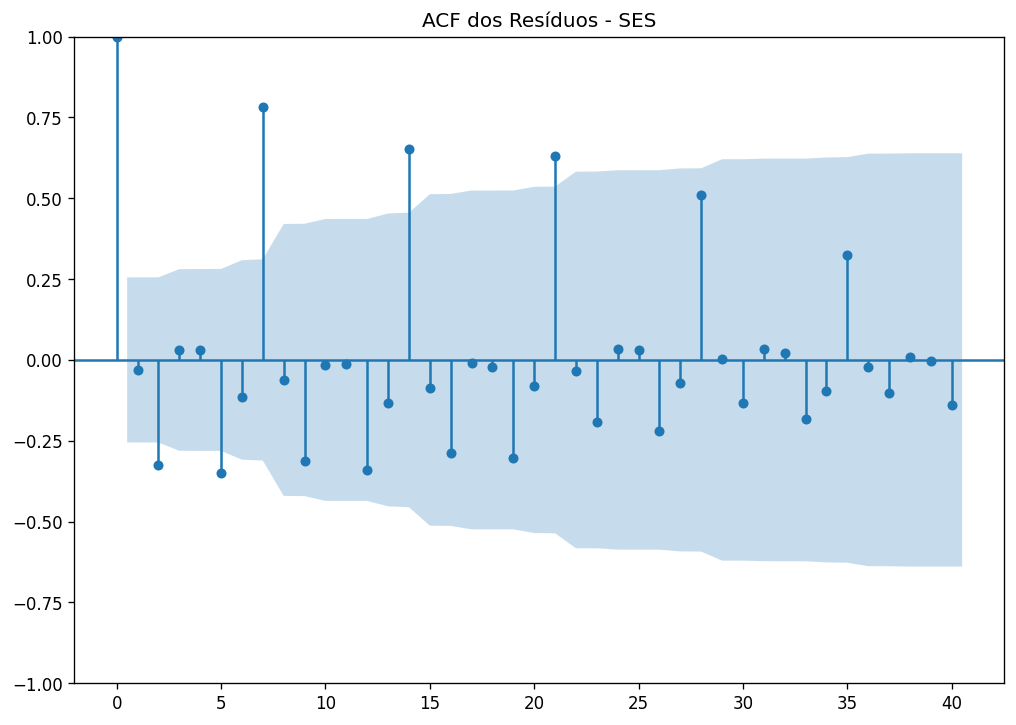

Teste de Ljung-Box - SES
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




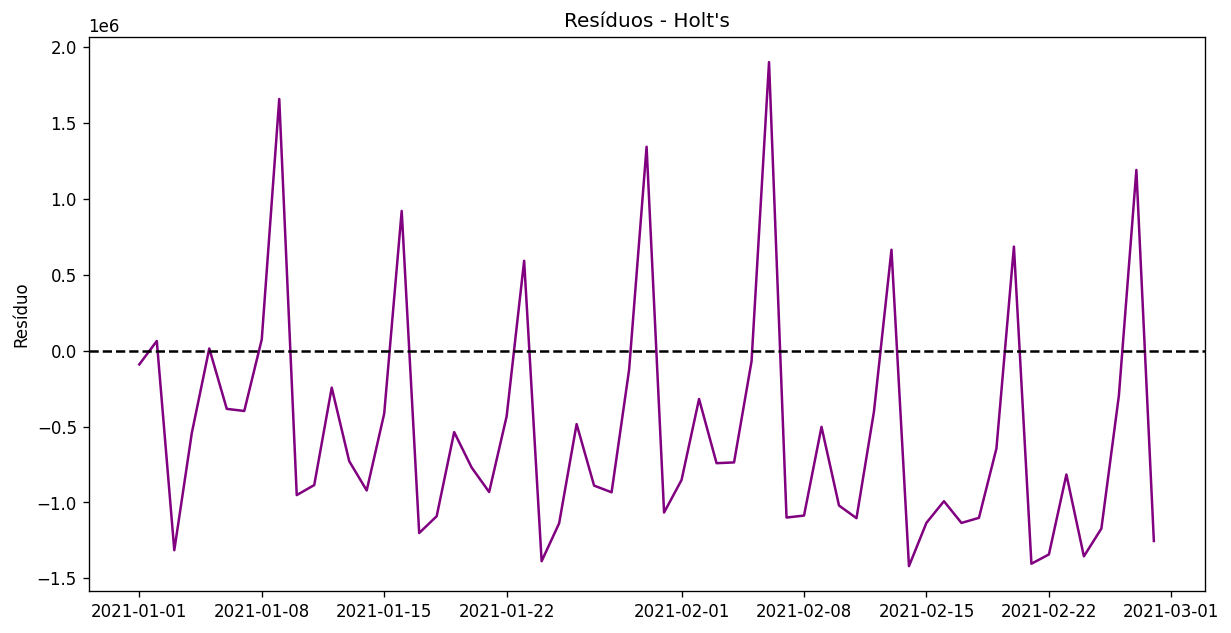

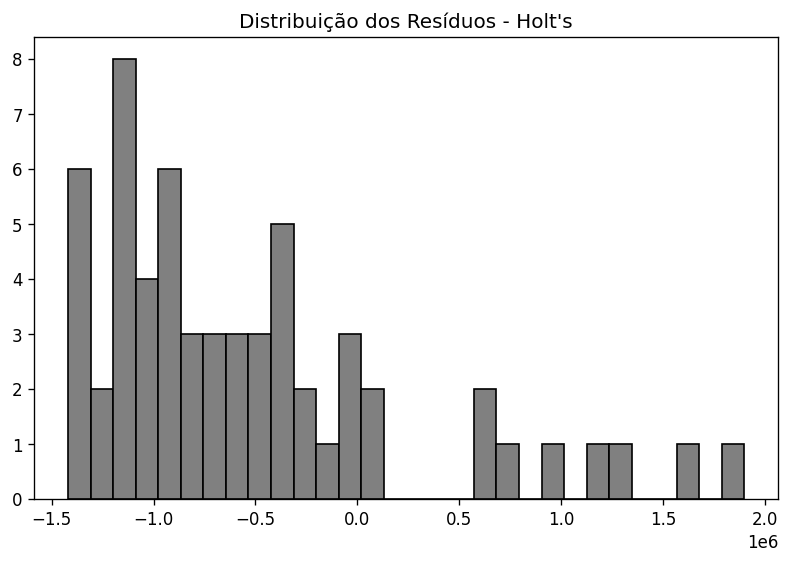

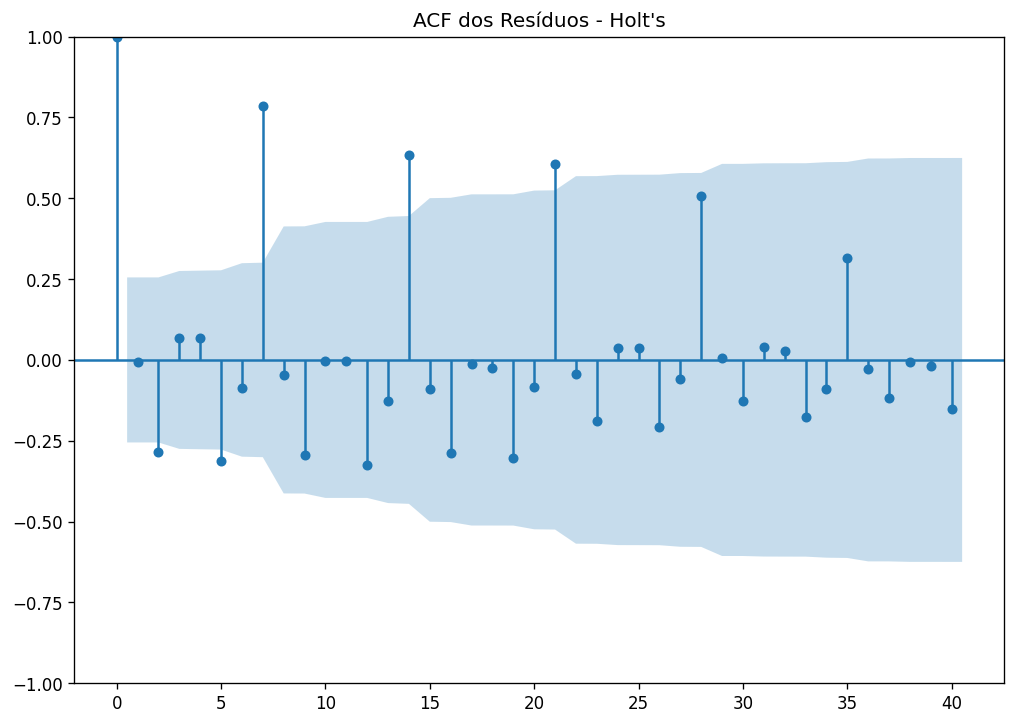

Teste de Ljung-Box - Holt's
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




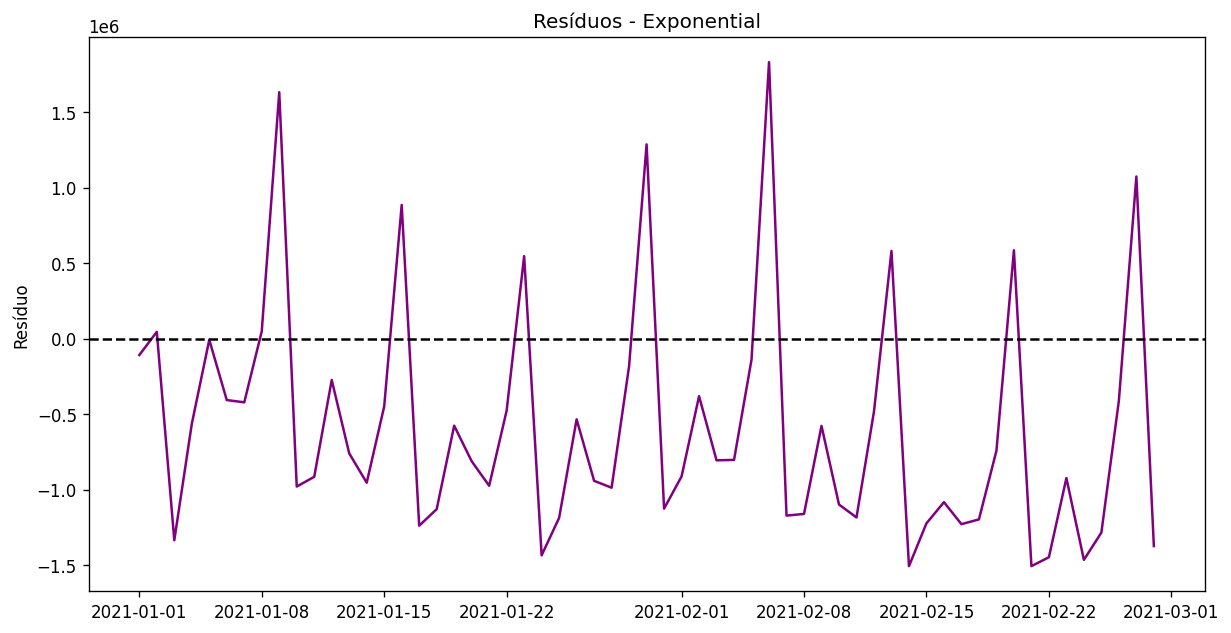

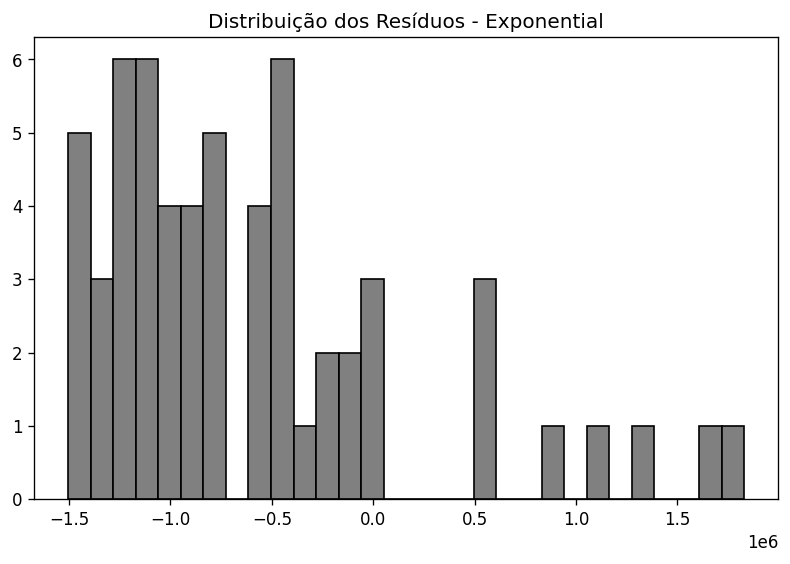

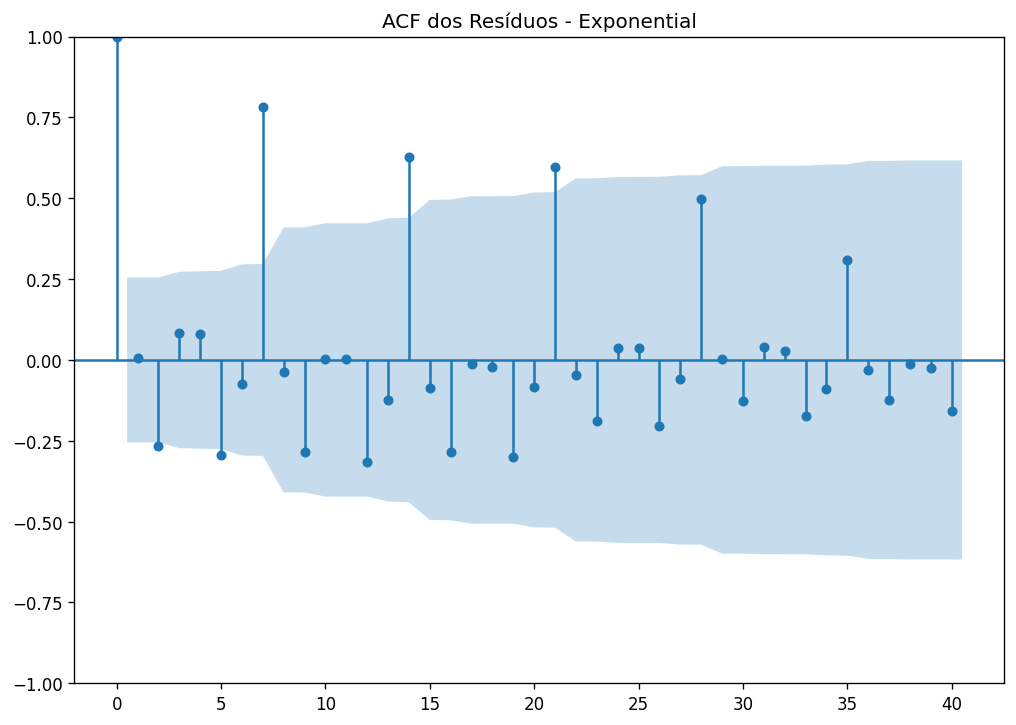

Teste de Ljung-Box - Exponential
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




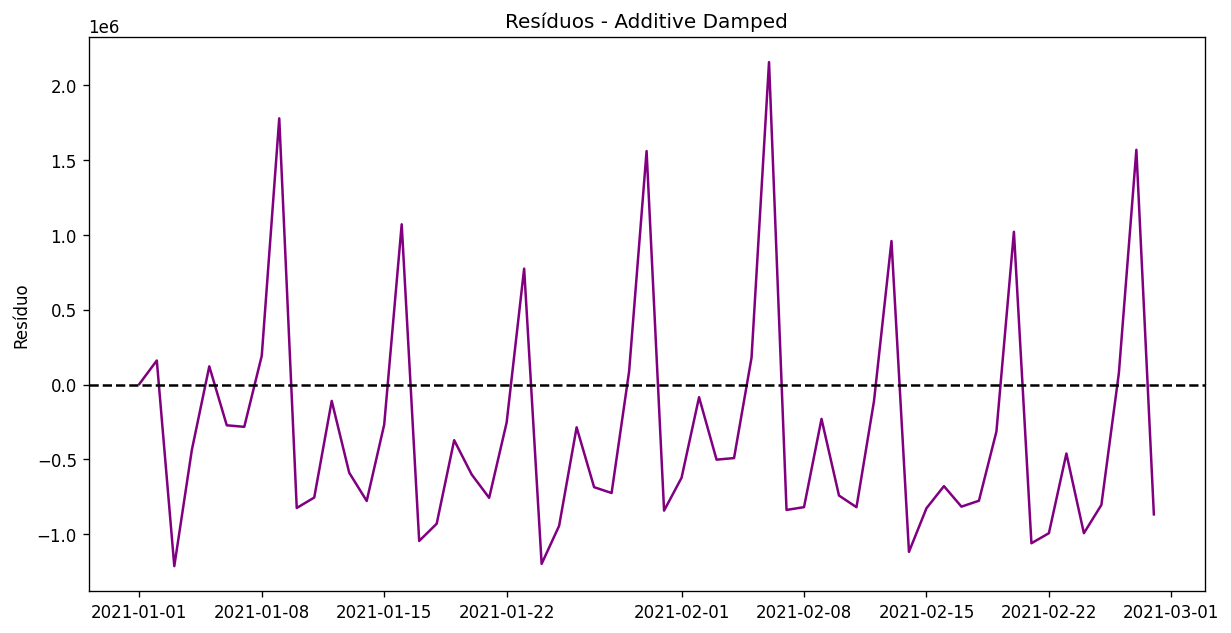

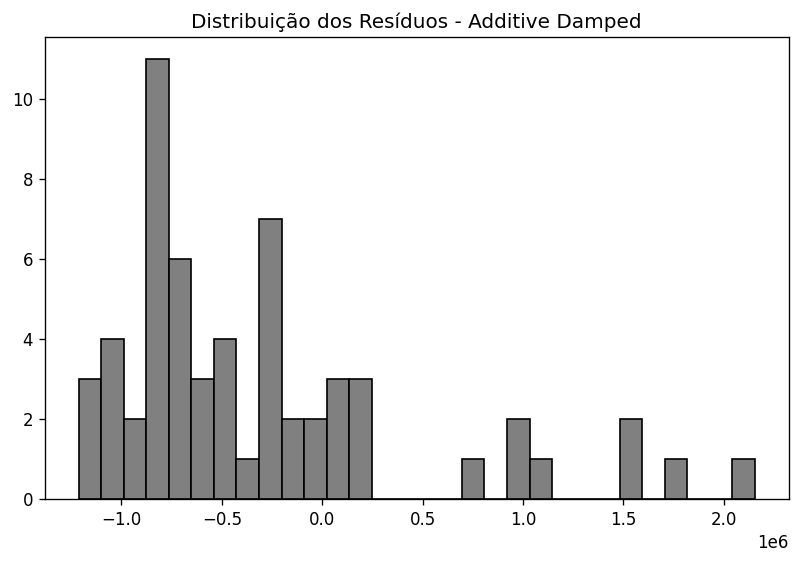

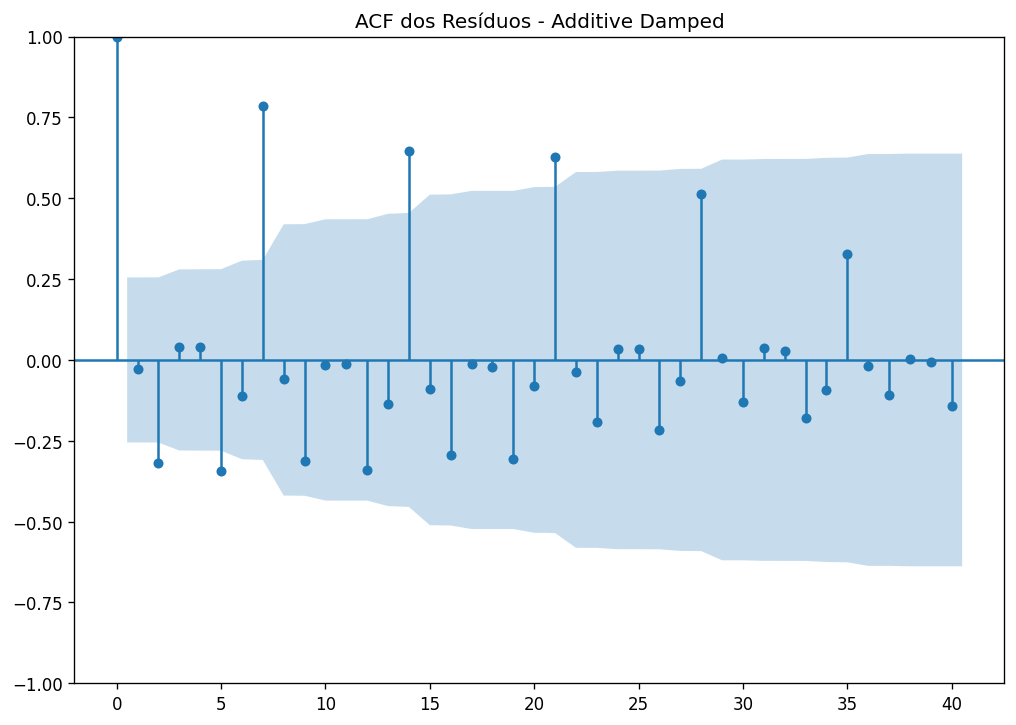

Teste de Ljung-Box - Additive Damped
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




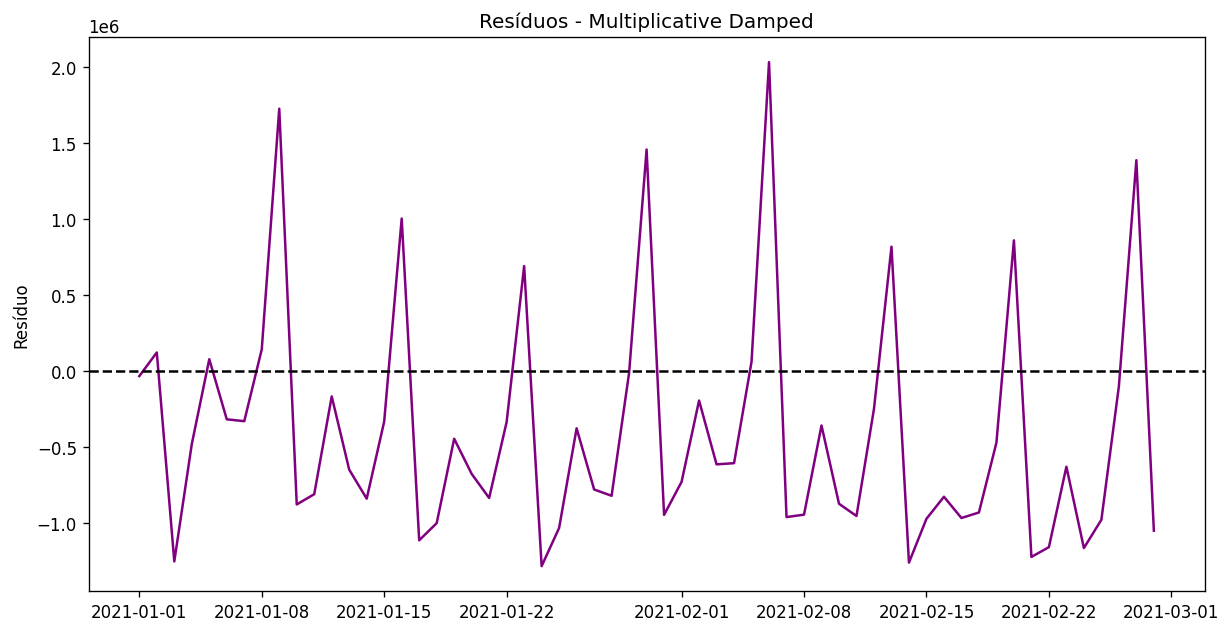

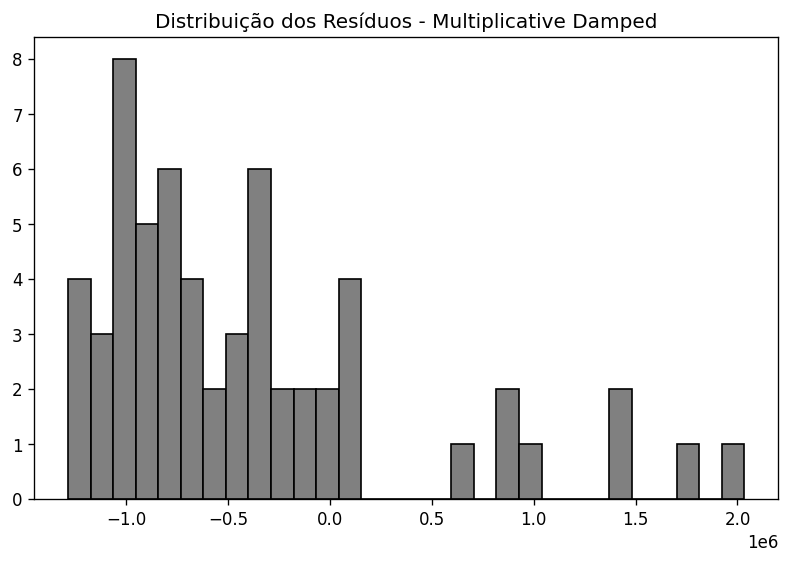

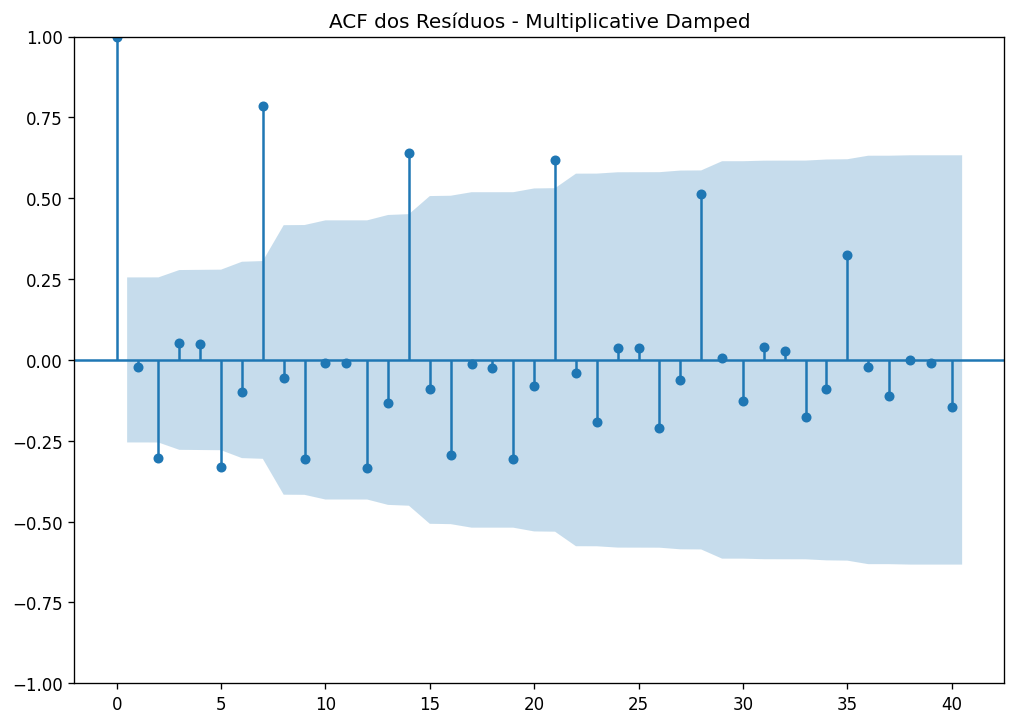

Teste de Ljung-Box - Multiplicative Damped
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




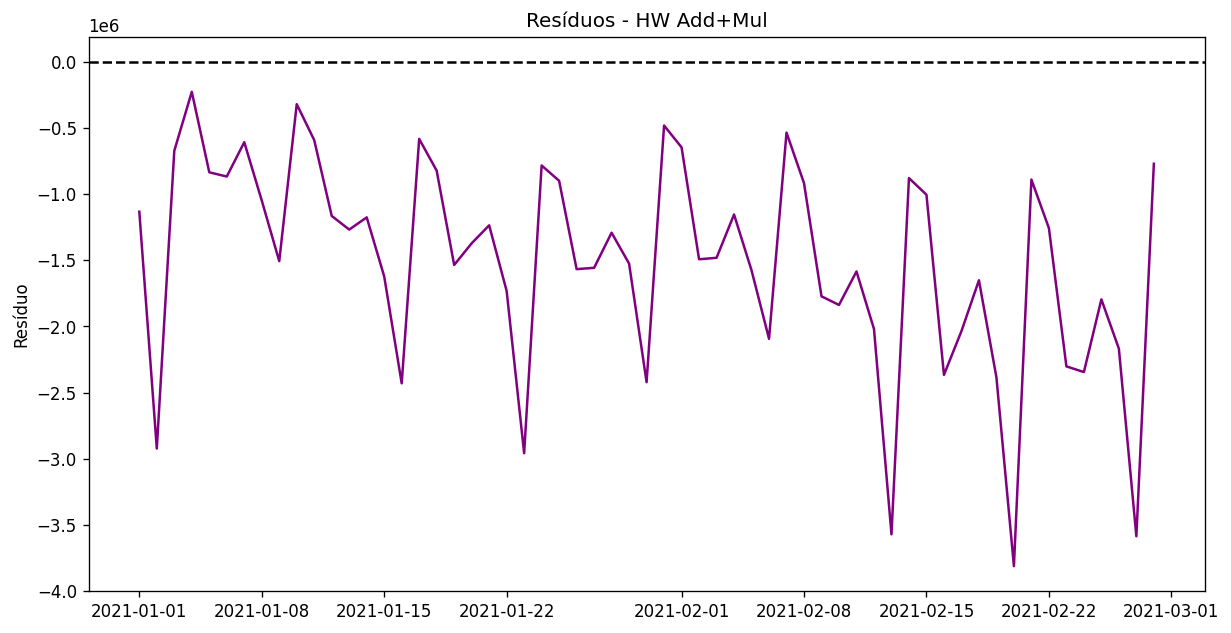

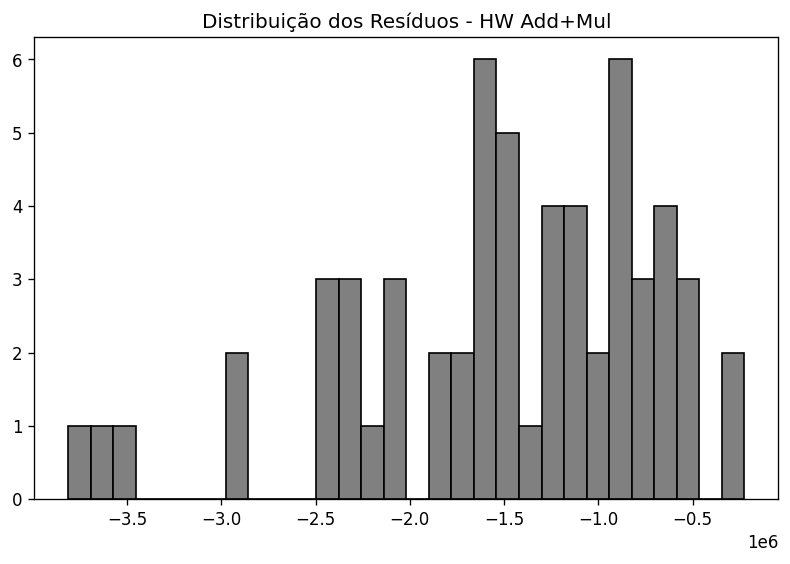

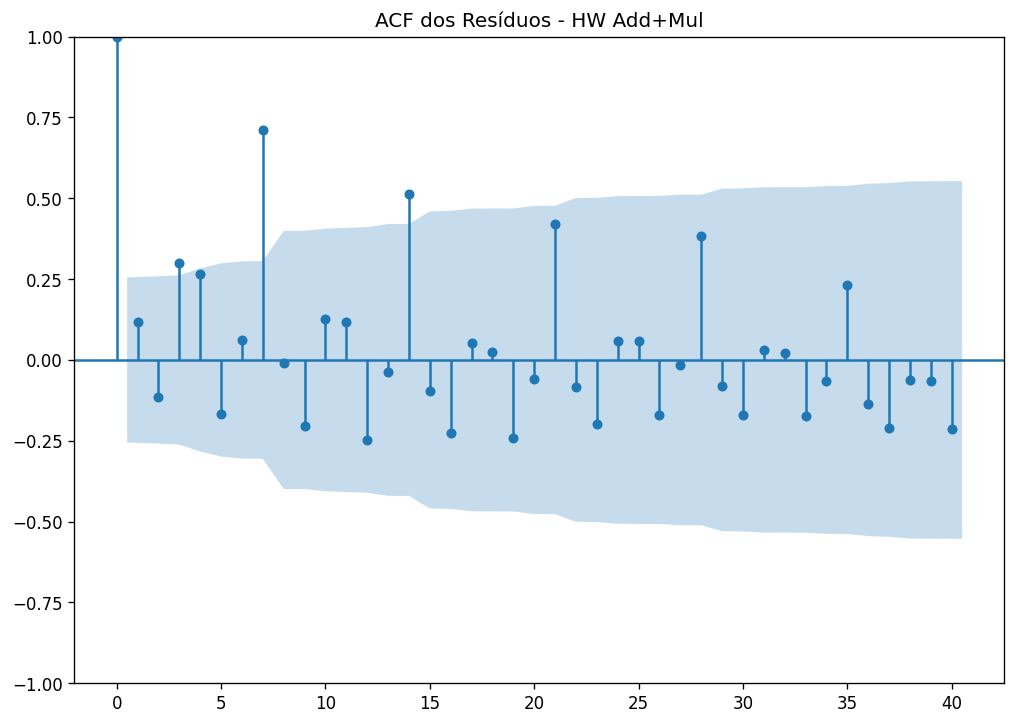

Teste de Ljung-Box - HW Add+Mul
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




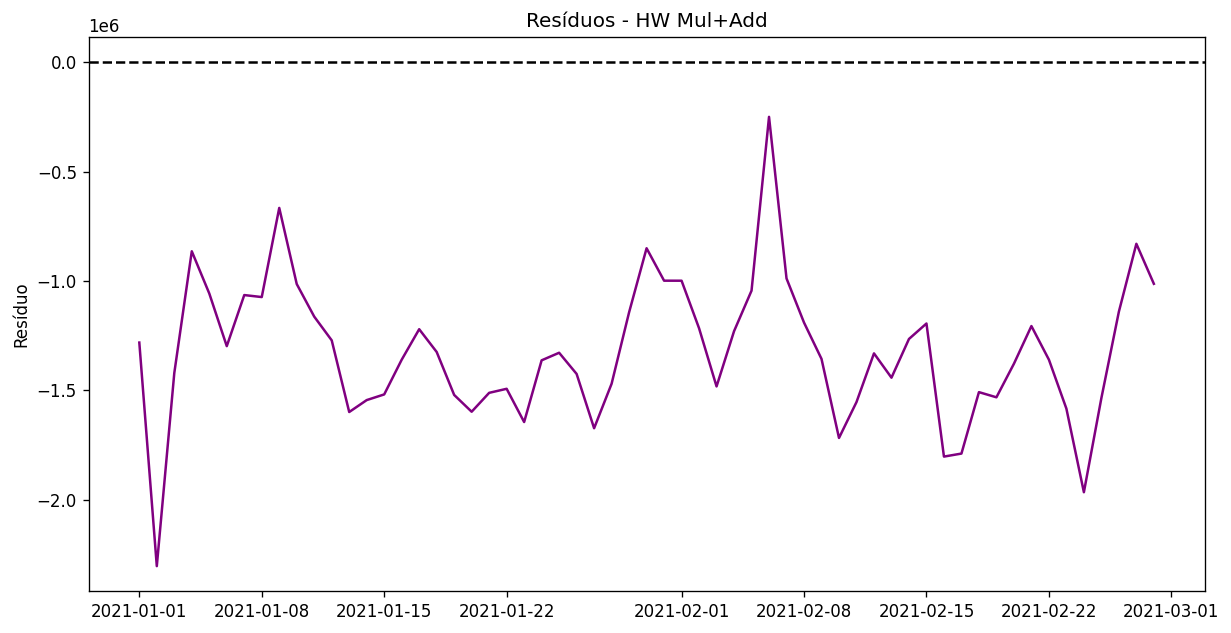

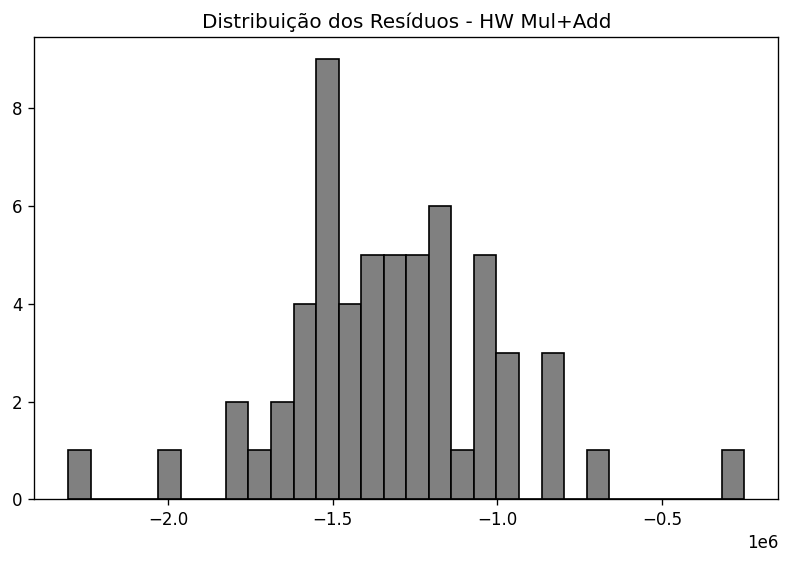

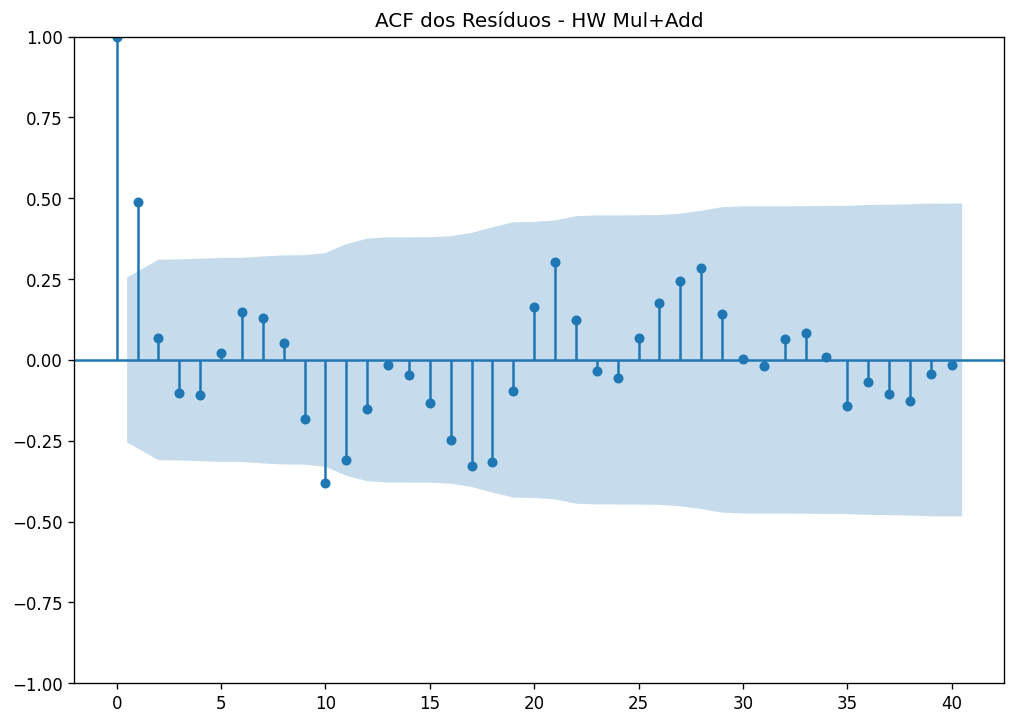

Teste de Ljung-Box - HW Mul+Add
Lag 7: p-valor=0.0078 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0001 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




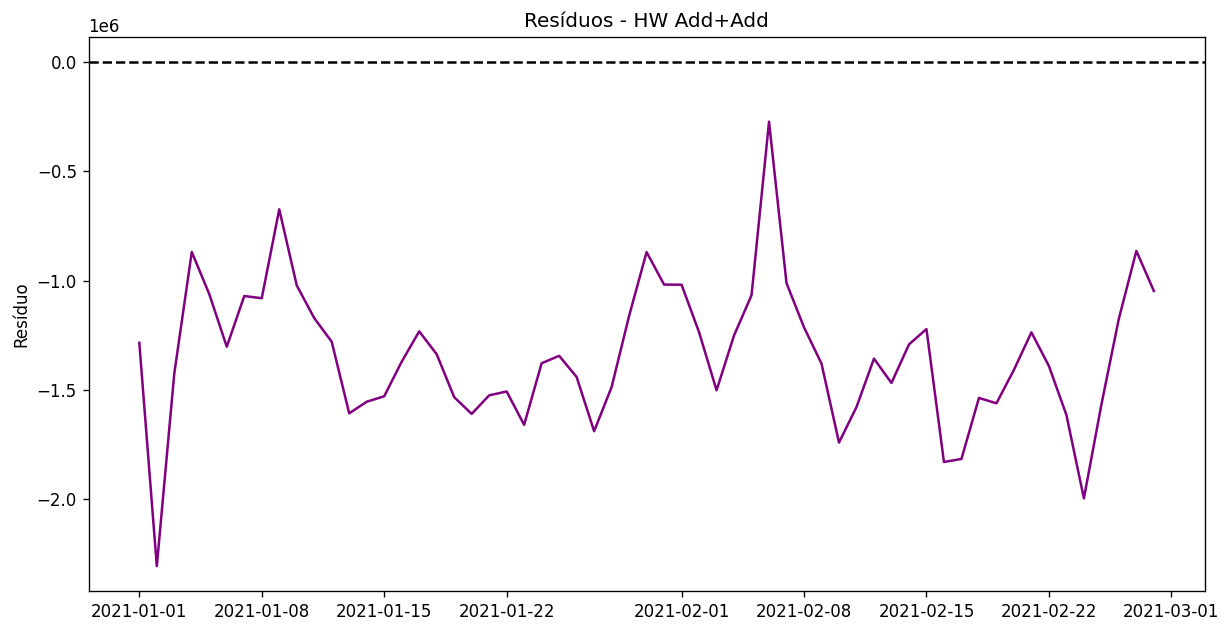

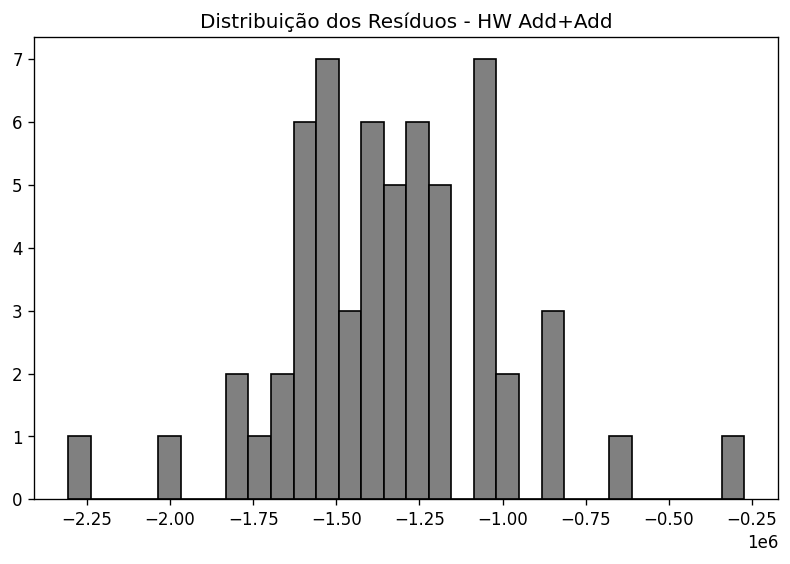

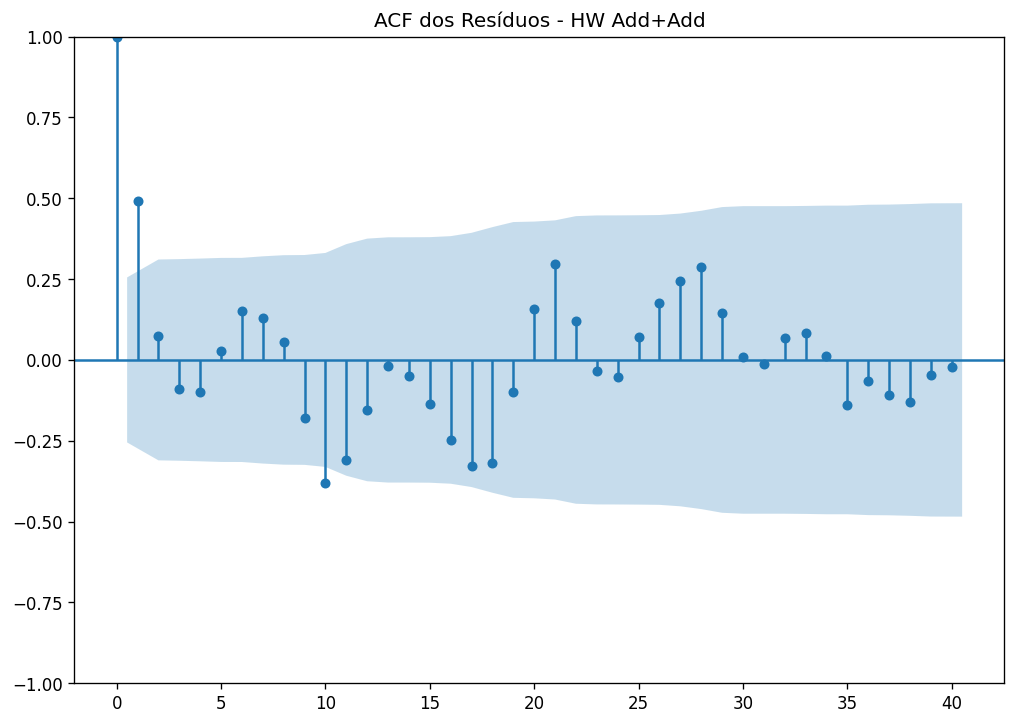

Teste de Ljung-Box - HW Add+Add
Lag 7: p-valor=0.0074 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0001 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




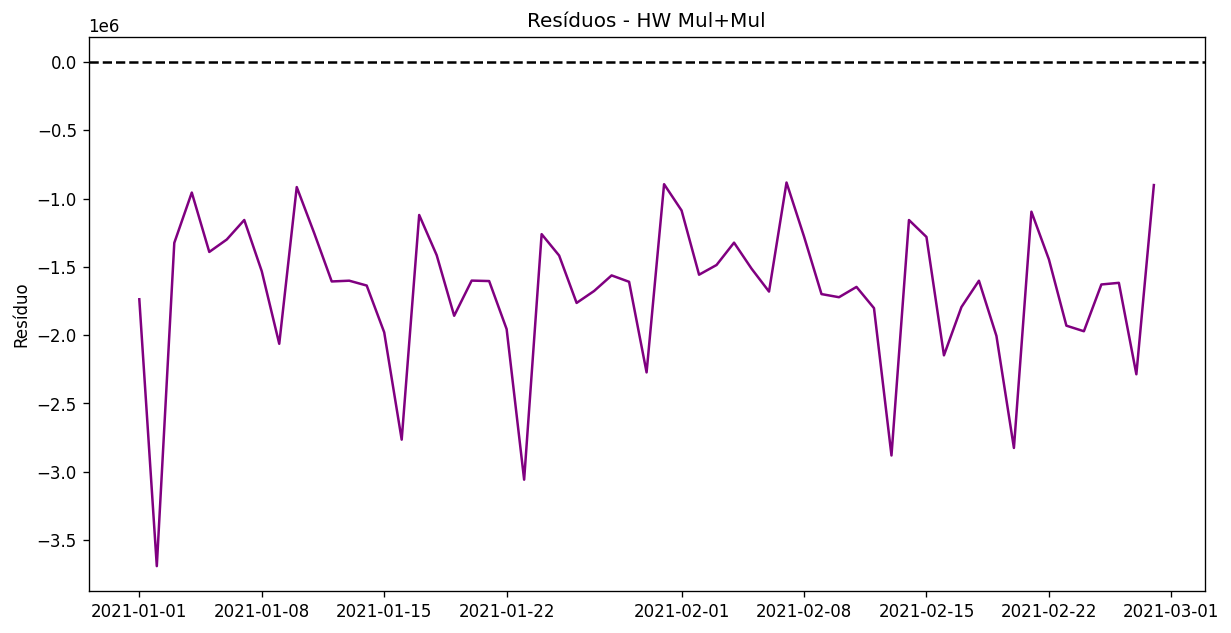

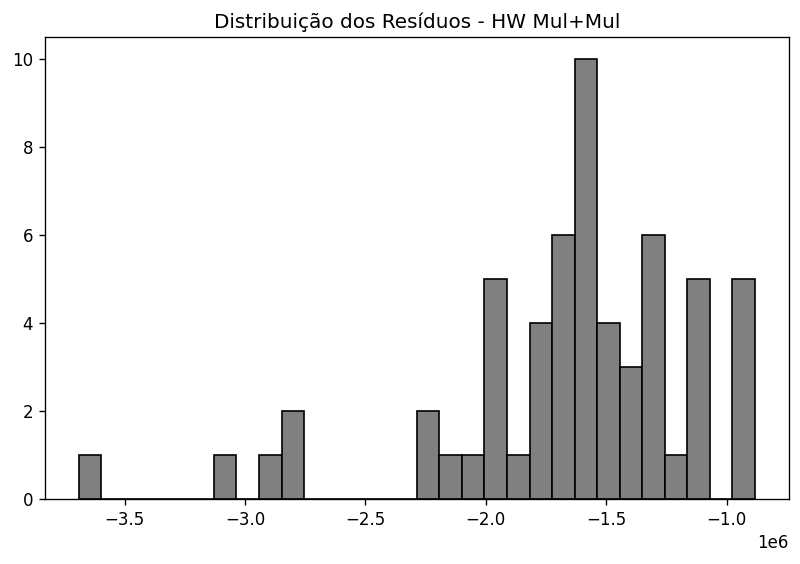

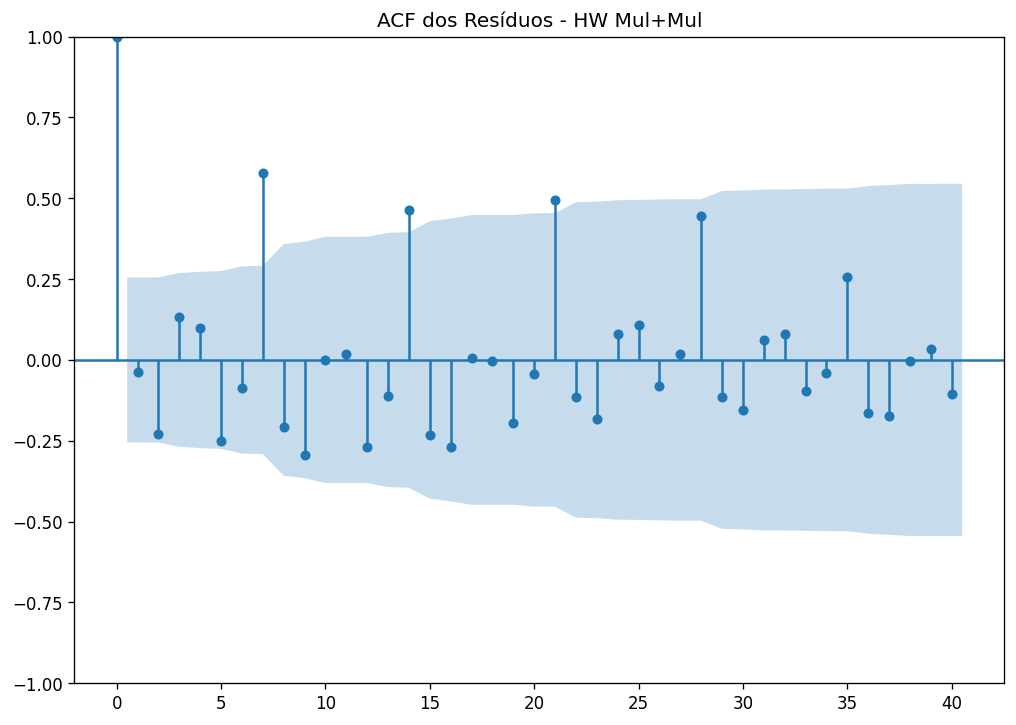

Teste de Ljung-Box - HW Mul+Mul
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




In [108]:
# Estudo de Resíduos

def analisar_residuos(nome, real, previsto):
    # Calcular resíduos
    residuos = real - previsto

    # Plot temporal
    plt.figure(figsize=(12,6))
    plt.plot(teste['Data_BR'], residuos, color='purple')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Resíduos - {nome}")
    plt.ylabel("Resíduo")
    plt.show()

    # Histograma
    plt.figure(figsize=(8,5))
    plt.hist(residuos, bins=30, color='gray', edgecolor='black')
    plt.title(f"Distribuição dos Resíduos - {nome}")
    plt.show()

    # ACF
    sm.graphics.tsa.plot_acf(residuos, lags=40)
    plt.title(f"ACF dos Resíduos - {nome}")
    plt.show()

    # Teste de Ljung-Box (lags múltiplos da sazonalidade semanal)
    ljung = acorr_ljungbox(residuos, lags=[7, 14, 21], return_df=True)
    print(f"Teste de Ljung-Box - {nome}")
    for lag, row in ljung.iterrows():
        pvalor = row['lb_pvalue']
        if pvalor > 0.05:
            print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
        else:
            print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")
    print("\n")

# ============================
# 8. Rodar análise para todos os modelos
# ============================
for nome, forecast in models.items():
    analisar_residuos(nome, teste['Vendas'], forecast)